## About the Data

Titanic Passenger Data

The dataset contains information about passengers of RMS Titanic, which sank on April 15, 1912 after colliding with an iceberg. The data includes attributes such as travel class, age, gender, number of siblings/spouses on board, number of parents/children on board, ticket price, and port of embarkation.

The dataset also contains information about whether the passenger survived the disaster.

Titanic carried over 2,200 people, of whom over 1,500 perished, making this disaster one of the most tragic in maritime history.

Columns:

* **pclass** - Ticket class
* **survived** - Whether the passenger survived the disaster
* **name** - Passenger's name
* **sex** - Passenger's gender
* **age** - Passenger's age
* **sibsp** - Number of siblings/spouses on board
* **parch** - Number of parents/children on board
* **ticket** - Ticket number
* **fare** - Ticket price
* **cabin** - Cabin number
* **embarked** - Port where the passenger boarded (C = Cherbourg, Q = Queenstown, S = Southampton)
* **boat** - Lifeboat number
* **body** - Body number (if the passenger did not survive and the body was recovered)
* **home.dest** - Destination

In [15]:
import pandas as pd

In [16]:
df = pd.read_csv('26__titanic.csv', sep=",")
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1305,3.0,0.0,"Zabour, Miss. Thamine",female,NaN,1.0,0.0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3.0,0.0,"Zakarian, Mr. Mapriededer",male,26.5000,0.0,0.0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3.0,0.0,"Zakarian, Mr. Ortin",male,27.0000,0.0,0.0,2670,7.2250,NaN,C,NaN,NaN,NaN
1308,3.0,0.0,"Zimmerman, Mr. Leo",male,29.0000,0.0,0.0,315082,7.8750,NaN,S,NaN,NaN,NaN


## The first glance raises questions.

Is it possible to conduct a reliable analysis of factors affecting passenger survival based solely on demographic and social data (gender, age, travel class, family presence), despite the lack of information about the evacuation process, decision-making system, and rescue logistics?

### What can and cannot be inferred from this data?
Can:
- Statistically determine which demographic and social characteristics (gender, age, class, family presence) correlate with higher or lower survival rates.
- Build predictive models predicting survival based on these characteristics.
- Check whether there are statistically significant differences between passenger groups.

Cannot:
- Draw conclusions about the actual causes of survival or death (e.g., impact of crew decisions, evacuation process).
- Assess how the rescue process proceeded and whether women and children were actually evacuated first based solely on passenger data.
- Include in models factors for which data is missing (such as chaos on deck, time to reach lifeboats).


## So let's get to work...

## Objective of the Analysis

The aim of this project is to understand how the demographic and social characteristics of Titanic passengers (such as gender, age, travel class, or the presence of family members) were associated with statistical differences in survival during the disaster.

This analysis is not intended to reconstruct the evacuation process or determine the causes of individual survival or death cases, because the dataset does not contain information about crew decisions, evacuation order, rescue logistics, or on-board conditions.

I want to answer the following questions:
- Do selected demographic and social characteristics of passengers correlate with survival rates?
- Which variables (e.g. class, gender, age, number of family members) show a statistically significant relationship with survival?
- Can I build simple predictive models that estimate survival based on the available features?
- To what extent do data quality and completeness affect the reliability of the analysis?

**Disclaimer:** This analysis is correlational and statistical in nature. I am not able to determine causal mechanisms of survival nor reconstruct the evacuation process.

---

## *But (there always has to be a small “but”), I allow myself to step slightly outside the brackets...

Although the main focus of my analysis is on tabular data describing Titanic passengers (such as age, gender, travel class, ticket number, or port of embarkation), I consider it important to take historical context into account from the very beginning.

The dataset does not include information about the evacuation process, the crew’s decision-making system, or rescue logistics, which significantly limits my ability to fully understand the mechanisms influencing survival.

Therefore, in my analysis:
- I consciously incorporate historical knowledge derived from survivor accounts, investigative reports, and research on the disaster,
- I treat this knowledge as a set of auxiliary assumptions that serve as a reference point for interpreting my results,
- I allow myself a small margin to adopt certain assumptions that may help the analysis, and that I will later attempt to confirm or refute.

---

### Examples of historical findings:
1. **The “women and children first” rule was applied unevenly**
   - Port side (Officer Lightoller): strict enforcement - men only as a last resort.
   - Starboard side (Officer Murdoch): more flexible approach - men boarded when seats were available.
2. **The evacuation was chaotic and inefficient**
   - Some lifeboats were launched with minimal occupancy, despite being able to carry many more people.
3. **Travel class influenced chances of rescue**
   - First-class passengers had easier access to the lifeboat decks.
   - Third-class passengers were often restricted by barriers and informationally isolated.
4. **Families were separated**
   - Women and children were separated from men - some women chose not to evacuate in order to stay with their relatives.
5. **Port of embarkation may be indirectly linked to social status**
   - Cherbourg was often chosen by first-class passengers.

---

### Auxiliary assumptions I adopt in this analysis:

| Assumption | Rationale | Potential risk |
|-----------|-----------|----------------|
| **Gender and age** may have increased survival chances | Supported by survivor accounts and partially by historical data | The “women and children first” rule was applied inconsistently |
| **Travel class** affected access to lifeboats | Better access to upper decks and fewer physical barriers for first class | Not every first-class passenger survived |
| **Presence of family** may have influenced decisions and behaviour | Possible family separation and differing evacuation strategies | Difficult to interpret unambiguously, variable relationship |
| **Port of embarkation (Embarked)** may correlate with socioeconomic status | Cherbourg was a common embarkation point for first-class passengers | Correlation may be weak or ambiguous |

---

### Purpose of these assumptions:
- In later stages of my analysis, I will attempt to empirically confirm or reject the above assumptions through data exploration, descriptive statistics, and predictive models.
- This approach aims not only to analyse the data itself, but also to critically assess its meaning in light of the historical context, which may help explain observed patterns or reveal their limitations.


## STARTING EXPLORATION AND DATA PREPARATION

Before we proceed to the actual analysis of variables and attempts to formulate conclusions, we must examine **data completeness**. Missing data can significantly affect the reliability of the analysis, distort statistics, and lead to erroneous conclusions if not properly handled.

Therefore, the first step will be:
- checking **which columns contain missing data**,
- determining **what percentage they represent**,
- preliminary consideration of strategies for handling these gaps (imputation, removal, keeping as a separate category, etc.).

In the next cell, we will perform an analysis of the number and percentage share of missing values in each column.

### How many missing values does each column have?

In [4]:
df.isna().sum()

pclass          1
survived        1
name            1
sex             1
age           264
sibsp           1
parch           1
ticket          1
fare            2
cabin        1015
embarked        3
boat          824
body         1189
home.dest     565
dtype: int64

### For greater clarity, we will sort columns in descending order by number of missing values and calculate the percentage of missing data.

Tabela braków danych (posortowana):

           Brakujące  Dostępne  Razem  Braki [%]
body            1189       121   1310      90.76
cabin           1015       295   1310      77.48
boat             824       486   1310      62.90
home.dest        565       745   1310      43.13
age              264      1046   1310      20.15
embarked           3      1307   1310       0.23
fare               2      1308   1310       0.15
sibsp              1      1309   1310       0.08
name               1      1309   1310       0.08
survived           1      1309   1310       0.08
pclass             1      1309   1310       0.08
sex                1      1309   1310       0.08
parch              1      1309   1310       0.08
ticket             1      1309   1310       0.08


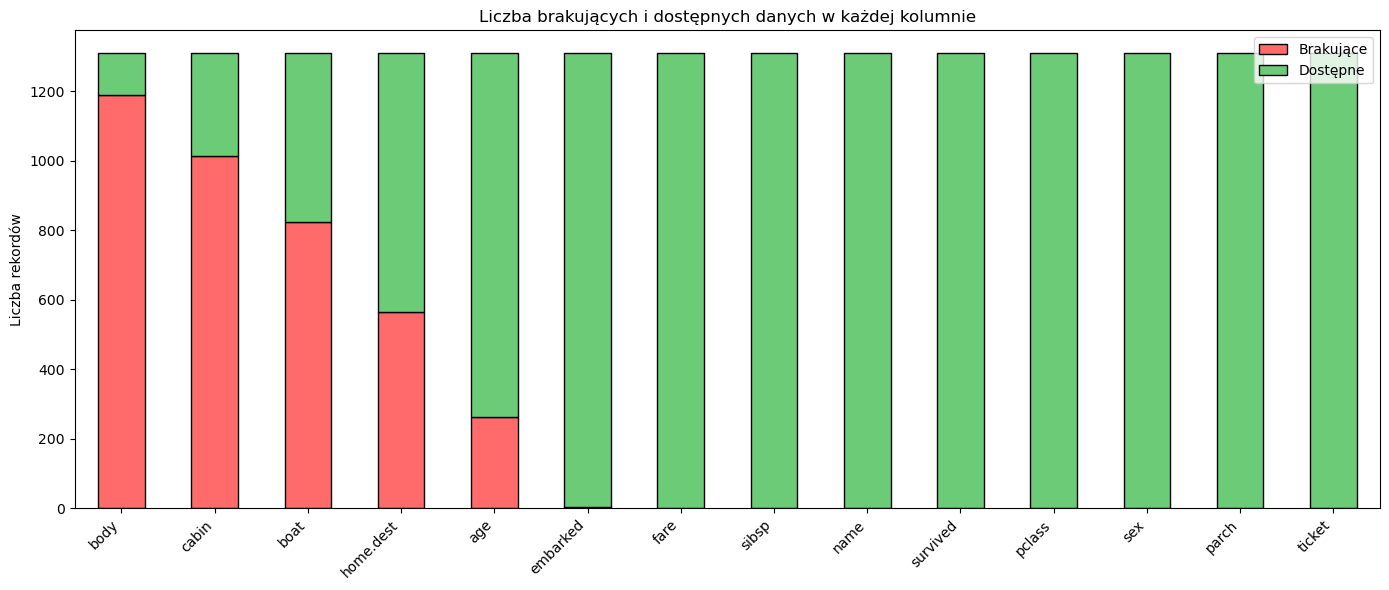

In [ ]:
import matplotlib.pyplot as plt

missing_data = df.isna().sum()
present_data = df.notna().sum()

summary = pd.DataFrame({
    'Missing': missing_data,
    'Available': present_data,
    'Total': df.shape[0],
    'Missing [%]': (missing_data / df.shape[0] * 100).round(2)
})

summary = summary.sort_values(by='Missing', ascending=False)

print("Missing data table (sorted):\n")
print(summary)

summary[['Missing', 'Available']].plot(
    kind='bar',
    stacked=True,
    figsize=(14, 6),
    color=['#FF6B6B', '#6BCB77'],  
    edgecolor='black'
)

plt.title("Number of missing and available data in each column")
plt.ylabel("Number of records")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.legend(loc='upper right')
plt.show()

### Conclusions from missing value analysis in columns:
**Seven columns contain only single missing values** - their completeness is very high and should not cause problems in the analysis.
`Fare` has **2 missing values**, and `Embarked` - **3**, which also represents a negligibly low level of missing data.
**The remaining five columns** already have significant gaps:
- Body - missing data in **over 95**% of cases; the column is practically useless in statistical analysis.
- Cabin - missing data in **over 77**% of records, which significantly limits the possibility of analysis without advanced imputation or aggregation.
- Boat - **62.9**% **missing**; although still a large percentage, the column may have potential analytical value in the context of evacuation and should be analyzed individually.

### The distribution of missing values is uneven - it is concentrated mainly in a few columns, which means that most of the dataset is consistent and suitable for analysis. Demographic and social data (gender, age, class, etc.) are largely complete, which allows continuing the analysis according to previously adopted assumptions.



---

### How many missing values does each row have?

In [ ]:
num_rows_with_na = df.isna().any(axis=1).sum()
print(f"Number of rows with at least one missing value: {num_rows_with_na}")

Liczba wierszy z co najmniej jednym brakiem: 1310


### Surprising result: in the entire dataset `there is not a single row free of missing values,` each of the 1310 records contains at least one unfilled value. This means that the data is not only incomplete pointwise (in columns), but also *systematically inconsistent at the row level*, which will be important in further analysis and potential data cleaning.

### Examining the distribution of missing values per row

Liczba wierszy z daną liczbą braków:

1     186
2     290
3     399
4     278
5     156
14      1
dtype: int64


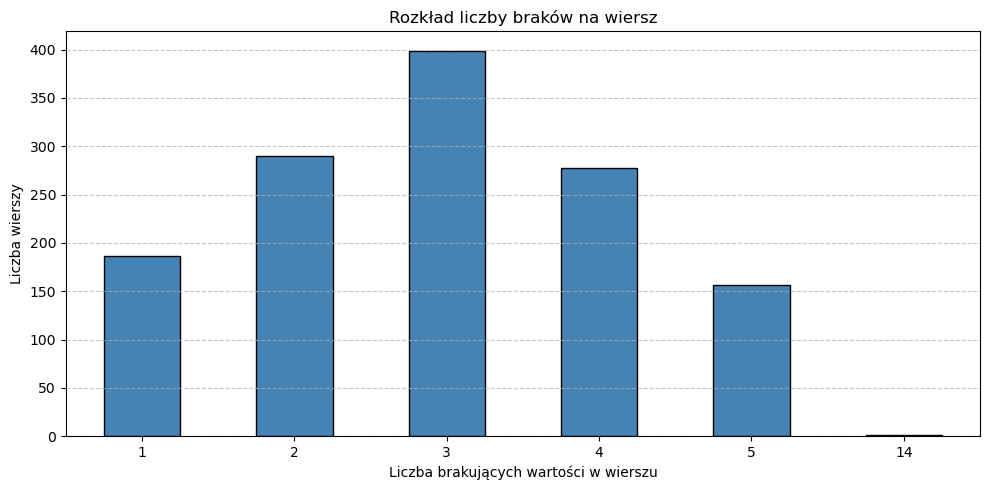

In [ ]:
row_missing_counts = df.isna().sum(axis=1)

distribution = row_missing_counts.value_counts().sort_index()

print("Number of rows with a given number of missing values:\n")
print(distribution)

distribution.plot(kind='bar', figsize=(10, 5), color="#4682B4", edgecolor="black")
plt.title("Distribution of missing values per row")
plt.xlabel("Number of missing values in row")
plt.ylabel("Number of rows")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### We already have a certain picture of the distribution of missing values at the row level, but let’s take it one step further...


### We check which columns contain missing values for rows with exactly 5, 4, 3, 2, and 1 missing value, in order to understand which fields most often “drop out” in partially incomplete records.


In [ ]:
def analyze_missing_for_row_count(df, n_missing):
    rows_with_n_nans = df[df.isnull().sum(axis=1) == n_missing]
    print(f"\n{'='*50}")
    print(f"Number of rows with exactly {n_missing} missing values: {len(rows_with_n_nans)}")
        
    missing_counts = rows_with_n_nans.isnull().sum()
    missing_counts = missing_counts[missing_counts > 0]

    if not missing_counts.empty:
        print(f"Missing values occur in the following columns (for {n_missing} missing):")
        print(missing_counts)
    else:
        print("No missing values in these rows (which would be unusual).")

for n in [5, 4, 3, 2, 1]:
    analyze_missing_for_row_count(df, n)


Liczba wierszy z dokładnie 5 brakującymi wartościami: 156
Braki występują w następujących kolumnach (dla 5 braków):
age          156
cabin        156
boat         156
body         156
home.dest    156
dtype: int64

Liczba wierszy z dokładnie 4 brakującymi wartościami: 278
Braki występują w następujących kolumnach (dla 4 braków):
age           71
fare           1
cabin        274
boat         237
body         276
home.dest    253
dtype: int64

Liczba wierszy z dokładnie 3 brakującymi wartościami: 399
Braki występują w następujących kolumnach (dla 3 braków):
age           26
cabin        384
embarked       1
boat         299
body         358
home.dest    129
dtype: int64

Liczba wierszy z dokładnie 2 brakującymi wartościami: 290
Braki występują w następujących kolumnach (dla 2 braków):
age           10
cabin        200
embarked       1
boat         104
body         239
home.dest     26
dtype: int64

Liczba wierszy z dokładnie 1 brakującymi wartościami: 186
Braki występują w następującyc

### Partially surprising result! 
`All rows with exactly 5 missing values have gaps in the same columns`, indicating a repeating pattern of missing values. Overall, this result is consistent with earlier observations from charts and column analyses.

### As Carl Friedrich Gauss once said: “Mathematics is the queen of the sciences, and arithmetic is the queen of mathematics”, so we will do some addition 😊


In [ ]:
missing_counts_list = [14, 5, 4, 3, 2, 1]

summary = {}

for n_missing in missing_counts_list:
    rows_with_n_missing = df[df.isnull().sum(axis=1) == n_missing]
    nulls_per_column = rows_with_n_missing.isnull().sum()
    summary[n_missing] = nulls_per_column

summary_df = pd.DataFrame(summary)

summary_df["Total_missing"] = df.isnull().sum()

ordered_columns = [14, 5, 4, 3, 2, 1, "Total_missing"]
summary_df = summary_df[ordered_columns]

summary_df = summary_df.sort_values(by="Total_missing", ascending=False)

print("Sorted summary of missing values by total number of missing (descending):")
print(summary_df)

Posortowane zestawienie braków wg całkowitej liczby braków (malejąco):
           14    5    4    3    2    1  Suma_braków_łącznie
body        1  156  276  358  239  159                 1189
cabin       1  156  274  384  200    0                 1015
boat        1  156  237  299  104   27                  824
home.dest   1  156  253  129   26    0                  565
age         1  156   71   26   10    0                  264
embarked    1    0    0    1    1    0                    3
fare        1    0    1    0    0    0                    2
sibsp       1    0    0    0    0    0                    1
name        1    0    0    0    0    0                    1
survived    1    0    0    0    0    0                    1
pclass      1    0    0    0    0    0                    1
sex         1    0    0    0    0    0                    1
parch       1    0    0    0    0    0                    1
ticket      1    0    0    0    0    0                    1


### Analysis of missing values in rows confirmed earlier observations regarding columns. The sum of missing values checked for columns and rows are identical.

## Overall Conclusions from Missing Data Analysis
Missing values occur in every column and every row; there is not a single column or row free of missing values.
The scale of missing values in columns is varied, but most columns contain a relatively small number of missing values (1–3).
Several columns are characterized by a very large number of missing values:
- body - over 95% missing; data in this column is almost useless.
- cabin - over 77% missing; additionally contains difficult-to-process multiple entries.
- boat - approximately 63% missing; additionally contains information available only after the disaster (may lead to data leakage in predictive models).

Analysis of the distribution of missing values in rows confirmed earlier observations:
- Rows with 1–3 missing values dominate.
- There is one row with missing values in all columns (14 missing), which has been deemed useless and marked for removal.

Column body - should be excluded from analysis - contains extremely many missing values (over 90%) and does not directly contribute useful analytical information.
Column cabin - should also be removed - despite potential value (e.g., cabin location), its imputation would be too uncertain due to missing more than half of the data.
Column boat - raises doubts, although it could suggest participation in evacuation, its predictive value in the context of models (e.g., predicting survival) is limited, because it is an effect, not a cause of survival. However, it can be used as an auxiliary for model validation or in exploratory analysis.

The distributions of missing values in columns and rows overlap; missing values appear systematically in the same variables and are confirmed both visually and numerically. The data is ready for further analysis and partial processing.

### Decision to Remove Row with 14 Missing Values
A row with 14 missing values out of 14 columns is practically empty, so it has no analytical value. 
Removing it is the best solution. 
The only "value" of this row is that it suggests the existence of one more passenger, but the lack of any data makes it analytically useless.
Removing this row will cause:
- the number of passengers in the DataFrame to decrease by one,
- but it will not affect the quality of analyses, rather it will increase their reliability; this row could distort statistics, e.g., when calculating means or training a model.

Despite removal, it is worth remembering that the original number of passengers is N + 1, where N is the number of rows after removing this entry. This can be included, for example, in the analysis documentation or at the reporting stage.

In [92]:
df = df[df.isnull().sum(axis=1) < 14]

Checking if the row without data has been removed

In [93]:
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,home.dest,travel_group_size,passengers_per_ticket,fare_per_person
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,2,"St Louis, MO",1.0,4.0,52.834375
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,11,"Montreal, PQ / Chesterville, ON",4.0,6.0,25.258333
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,"Montreal, PQ / Chesterville, ON",4.0,6.0,25.258333
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,"Montreal, PQ / Chesterville, ON",4.0,6.0,25.258333
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,"Montreal, PQ / Chesterville, ON",4.0,6.0,25.258333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3.0,0.0,"Zabour, Miss. Hileni",female,14.5000,1.0,0.0,2665,14.4542,NaN,C,NaN,NaN,2.0,2.0,7.227100
1305,3.0,0.0,"Zabour, Miss. Thamine",female,NaN,1.0,0.0,2665,14.4542,NaN,C,NaN,NaN,2.0,2.0,7.227100
1306,3.0,0.0,"Zakarian, Mr. Mapriededer",male,26.5000,0.0,0.0,2656,7.2250,NaN,C,NaN,NaN,1.0,1.0,7.225000
1307,3.0,0.0,"Zakarian, Mr. Ortin",male,27.0000,0.0,0.0,2670,7.2250,NaN,C,NaN,NaN,1.0,1.0,7.225000


---

### Before we proceed to the suggested removal of columns with the largest number of missing values (body, cabin, boat), we will take a step back and examine them in terms of data homogeneity.

### Despite the large number of missing values, it is equally important whether the data in these columns is consistent in terms of structure. For example, in the cabin column, there are cases where more than one value is recorded in a single cell (e.g., several cabins). Such irregularities can hinder further analysis and require additional data processing.

### Therefore, we will check whether similar problems occur in other columns.

In [ ]:
def has_multiple_values(cell):
    if isinstance(cell, str):
        return any(sep in cell for sep in [' ', ',', ';'])
    return False

multi_valued_summary = {}

for col in df.columns:
    count = df[col].apply(has_multiple_values).sum()
    if count > 0:
        multi_valued_summary[col] = count

result_df = pd.DataFrame.from_dict(multi_valued_summary, orient='index', columns=['Number of cells with multiple values'])
result_df.sort_values(by='Number of cells with multiple values', ascending=False, inplace=True)

print("Columns with suspicious multiple values in a single cell:\n")
print(result_df)

Kolumny z podejrzanymi wieloma wartościami w jednej komórce:

           Liczba komórek z wieloma wartościami
name                                       1309
home.dest                                   689
ticket                                      348
cabin                                        41
boat                                         10


### During the initial exploration, we noticed columns that may indicate that a single record represents more than one person. Below are our detailed observations:

`Name` - at first glance, it may appear to contain “multiple values” - in reality, it consists of at least four components (surname, title, first name, sometimes a middle name). This is not evidence of a group entry, but rather the structure of a personal name itself. Therefore, it is more reasonable to extract key components (e.g. the title) than to count spaces or commas.

`Home.Dest` - if multiple destinations are listed under a single entry, this may suggest multiple people with different final destinations. Additionally, the data appears in non-uniform formats (e.g. “City, ST” vs. “City, Country”) - this requires standardisation before analysis (for example, extracting only the country).

`Ticket` - we observed as many as 348 ticket numbers that appear more than once - this is a strong signal that a single record may represent more than one person.

`Cabin` - there are 41 cases where the Cabin column contains multiple cabin numbers within a single cell. This strongly suggests that the entry may represent more than one person or a shared reservation.

`Boat` - in some rows, more than one value appears in the Boat column. Given that each lifeboat should correspond to a single person, such cases may indicate data errors or an attempt to encode information about multiple individuals within one record. Alternatively, the notation could have been used if a person was transferred from one boat to another (low probability).


---

### Examining the `Name` column to see if one entry hides more people

In [ ]:
titles = ["Mr.", "Mrs.", "Miss", "Ms.", "Mx.", "Dr.", "Prof.", "Rev.", "Sir", "Dame", "Hon.", "Lord", "Lady", "Esq."]

def count_exact_titles(name):
    return sum(1 for title in titles if re.search(rf'\b{re.escape(title)}\b', name))

multiple_titles = df[df["name"].apply(count_exact_titles) > 1]

print(f"Number of rows with more than one title: {len(multiple_titles)}")
print(multiple_titles[["name"]])

Liczba wierszy z więcej niż jednym tytułem: 0
Empty DataFrame
Columns: [name]
Index: []


### The count_exact_titles function did not find any row in which the "name" column contains more than one title from the titles list.

### We will check for duplicate of the same title in the same row 

In [ ]:
def has_duplicate_title(name):
    if not isinstance(name, str):
        return False
    for title in titles:
        
        matches = re.findall(rf'\b{re.escape(title)}\b', name)
        if len(matches) > 1:
            return True
    return False

duplicate_title_rows = df[df['name'].apply(has_duplicate_title)]

print(f"Number of rows with repeated title: {len(duplicate_title_rows)}")
print(duplicate_title_rows[['name']])

Liczba wierszy z powtórzonym tytułem: 0
Empty DataFrame
Columns: [name]
Index: []


### No cases were found where two titles appeared within a single name, which weakens the hypothesis of “multiple individuals in a single row”.


---

### Examining the `home.dest` column
During initial data exploration, I tried to identify records containing more than one destination by analyzing the home.dest column. Initially, I applied a general function checking whether a cell contains one of the potential separators: space (' '), comma (',') or semicolon (';').
Based on this, as many as 689 rows were identified as potentially containing multiple values. However, this method overinterprets the text structure, treating, for example, "New York, NY" or "London England" as multi-value entries, even though they represent a single location in different formats.

After a more detailed analysis of the data, I noticed that actual double destinations are consistently separated by a slash (/). Therefore, a re-analysis was conducted, taking into account mainly this separator as an indicator of multiple locations in one cell.

In [ ]:
import re
separators = ['/', ';', '&', '-', '|', '+']

separator_counts = {}

for sep in separators:
    count = df['home.dest'].dropna().str.contains(re.escape(sep)).sum()
    separator_counts[sep] = count

print("Number of occurrences of each separator in the 'Home.Dest' column:")
for sep, count in separator_counts.items():
    print(f"'{sep}': {count}")

Liczba wystąpień każdego separatora w kolumnie 'Home.Dest':
'/': 171
';': 0
'&': 0
'-': 10
'|': 0
'+': 0


### The updated approach showed only 171 rows that actually contain two different destinations. This means that the earlier result (689) contained a significant number of false positives.

In [ ]:
column = 'home.dest'

home_dest = df[column].dropna()

multi_dest_rows = home_dest[home_dest.str.contains('/')]

single_dest_rows = home_dest[~home_dest.str.contains('/')]

print(f"Number of rows with more than one destination: {len(multi_dest_rows)}")
print(f"Number of rows with one destination: {len(single_dest_rows)}")
print(f"Number of all non-empty rows: {len(home_dest)}")

Liczba wierszy z więcej niż jednym miejscem: 171
Liczba wierszy z jednym miejscem: 574
Liczba wszystkich niepustych wierszy: 745


### Data matches: 1309 rows - 745 non-empty rows = 564 missing (remember that one record was removed) 

### Initially, 10 records in the home.dest column containing the `-` character were identified. I am checking whether its presence may indicate multiple destinations (i.e., potential group entries), similar to the `/` separator.

In [ ]:
column = 'home.dest'

dash_destinations = df[column].dropna()
dash_destinations = dash_destinations[dash_destinations.str.contains('-')]

dash_counts = dash_destinations.value_counts()

print(f"Number of OCCURRENCES (total) of entries containing '-': {dash_counts.sum()}")
print(f"Number of UNIQUE values with '-': {dash_counts.shape[0]}\n")
print("All values with separator '-' and their count:\n")

for value, count in dash_counts.items():
    print(f"{value}  —  {count}x")

Liczba WYSTĄPIEŃ (łącznie) wpisów zawierających '-': 10
Liczba UNIKALNYCH wartości z '-': 8

Wszystkie wartości z separatorem '-' i ich liczność:

St Leonards-on-Sea, England Ohio  —  2x
Weston-Super-Mare, Somerset  —  2x
Westcliff-on-Sea, Essex  —  1x
Austria-Hungary / Germantown, Philadelphia, PA  —  1x
St Anne's-on-Sea, Lancashire  —  1x
Weston-Super-Mare / Moose Jaw, SK  —  1x
Harrow-on-the-Hill, Middlesex  —  1x
Austria-Hungary  —  1x


### Analysis showed that the `-` character in the home.dest column does not separate multiple destinations, but is part of the name of one city or region (e.g., St. Louis-MO, New York-NY). Therefore, we do not treat `-` as a separator when identifying group records.

---

### Examining the `Ticket` column to check if a single row contains more than one ticket number. Such a situation could suggest that one record describes more than one person or combines data from different reservations.

In [ ]:
import numpy as np

multiple_value_tickets = df[
    df['ticket'].notna() & df['ticket'].astype(str).str.contains(r'[ /,]')
]['ticket'].drop_duplicates()

sample_tickets = multiple_value_tickets.sample(n=40, random_state=42).reset_index(drop=True)

ticket_matrix = sample_tickets.values.reshape(4, 10).T
ticket_df = pd.DataFrame(ticket_matrix, columns=['Column 1', 'Column 2', 'Column 3', 'Column 4'])

print(ticket_df)

            Kolumna 1         Kolumna 2           Kolumna 3          Kolumna 4
0            PC 17610  C.A./SOTON 34068       SC/PARIS 2146  STON/O 2. 3101288
1          SC/AH 3085          PC 17756          F.C. 12750         C.A. 15185
2  SOTON/O.Q. 3101311           LP 1588       SC/Paris 2123          WE/P 5735
3  SOTON/O.Q. 3101308          PC 17611       S.O./P.P. 752  STON/O 2. 3101294
4            A/5 2466          PC 17572  SOTON/O.Q. 3101314             C 7075
5           C.A. 2673          PC 17613           C.A. 6212   SOTON/O2 3101284
6       SC/PARIS 2148        C.A. 42795            A/5 3594   STON/O2. 3101270
7          C.A. 29178     SC/Paris 2163       SC/PARIS 2149      SC/PARIS 2159
8   SOTON/O.Q. 392087         A.5. 3236          C.A. 31921         SO/C 14885
9             C 17368       S.O./P.P. 2       SC/PARIS 2133         A./5. 3235


### **Lack of clear examples of multiple ticket numbers in a single cell**

Each cell appears to contain a single ticket number, although the formats vary:
- sometimes they include letters and dots (e.g. `C.A. 15185`, `STON/O2. 3101290`)
- sometimes they resemble location codes (e.g. `S.C./PARIS 2079`, `WE/P 5735`)
- sometimes they are purely numeric (e.g. `PC 17613`, `PC 17474`)

None of the cells contains a typical separator (e.g. `,`, `;`, or a space separating two numbers followed by another number in the same format) that would suggest multiple ticket numbers within a single cell.

**Do multiple tickets actually occur in one cell?**  
There is no evidence of this in the provided subset of data. The initial assumption used in the function:

```python
def has_multiple_vals(cell):
    return any(sep in cell for sep in [' ', ',', ';'])
may have incorrectly classified some tickets as “containing multiple values” simply because they include spaces that are part of the ticket format itself (e.g. `PC 17613`, `C.A. 15185`), rather than acting as separators between multiple tickets.

Instead of relying on the presence of spaces, it is better to define a more precise rule, for example by detecting cases where a single cell contains two ticket-like strings separated by a comma or a semicolon.



In [8]:
import re

def has_multiple_ticket_like_values(cell):
    if isinstance(cell, str):
        matches = re.findall(r'([A-Z./]*\s?\d+)', cell.strip())
        return len(matches) > 1
    return False

### Code using the `has_multiple_ticket_like_values` function returned no results, which means that no cell in the `ticket` column contains multiple “ticket-like” values according to the current definition. Therefore, the data is consistently formatted and each cell contains only a single ticket.


### Following the thread further, we check if ticket numbers repeat in other rows

In [ ]:
ticket_counts = df['ticket'].value_counts()
shared_tickets = ticket_counts[ticket_counts > 1]

print(f"Number of tickets shared by more than one person: {len(shared_tickets)}")
print(shared_tickets.head(10)) 

Liczba biletów dzielonych przez więcej niż jedną osobę: 216
CA. 2343        11
1601             8
CA 2144          8
PC 17608         7
347082           7
347077           7
3101295          7
S.O.C. 14879     7
347088           6
113781           6
Name: ticket, dtype: int64


### The result shows that some ticket numbers (216) repeat multiple times

### Let's take a closer look...
I loaded a list of all rows with ticket numbers occurring more than once, but due to the size of the result (596 entries), the list was removed. I leave the ready code for review for those interested: 

duplicate_tickets = df['ticket'].value_counts()
duplicate_ticket_numbers = duplicate_tickets[duplicate_tickets > 1].index

df_duplicates = df[df['ticket'].isin(duplicate_ticket_numbers)]

df_duplicates = df_duplicates.sort_values(by='ticket')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None) 

df_duplicates.reset_index(drop=True, inplace=True)
df_duplicates

### Below is a list of 20 repeating numbers, for further analysis I selected two numbers pos. 17-19, 110413; pos. 20-21, 110813 

In [73]:
ticket_counts = df['ticket'].value_counts()
duplicate_tickets = ticket_counts[ticket_counts > 1].index

duplicate_ticket_rows = df[df['ticket'].isin(duplicate_tickets)]

required_tickets = ['110413', '110813']

available_tickets = list(set(duplicate_tickets) - set(required_tickets))
random.seed(42)
sampled_tickets = random.sample(available_tickets, 18)

final_ticket_list = required_tickets + sampled_tickets

sampled_rows = duplicate_ticket_rows[duplicate_ticket_rows['ticket'].isin(final_ticket_list)].copy()

sampled_rows.reset_index(drop=True, inplace=True)

sampled_rows

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1.0,1.0,"Appleton, Mrs. Edward Dale (Charlotte Lamson)",female,53.0,2.0,0.0,11769,51.4792,C101,S,D,NaN,"Bayside, Queens, NY"
1,1.0,1.0,"Bird, Miss. Ellen",female,29.0,0.0,0.0,PC 17483,221.7792,C97,S,8,NaN,NaN
2,1.0,1.0,"Brown, Mrs. John Murray (Caroline Lane Lamson)",female,59.0,2.0,0.0,11769,51.4792,C101,S,D,NaN,"Belmont, MA"
3,1.0,0.0,"Cumings, Mr. John Bradley",male,39.0,1.0,0.0,PC 17599,71.2833,C85,C,NaN,NaN,"New York, NY"
4,1.0,1.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,71.2833,C85,C,4,NaN,"New York, NY"
5,1.0,0.0,"Davidson, Mr. Thornton",male,31.0,1.0,0.0,F.C. 12750,52.0000,B71,S,NaN,NaN,"Montreal, PQ"
6,1.0,1.0,"Davidson, Mrs. Thornton (Orian Hays)",female,27.0,1.0,2.0,F.C. 12750,52.0000,B71,S,3,NaN,"Montreal, PQ"
7,1.0,1.0,"Dodge, Dr. Washington",male,53.0,1.0,1.0,33638,81.8583,A34,S,13,NaN,"San Francisco, CA"
8,1.0,1.0,"Dodge, Master. Washington",male,4.0,0.0,2.0,33638,81.8583,A34,S,5,NaN,"San Francisco, CA"
9,1.0,1.0,"Dodge, Mrs. Washington (Ruth Vidaver)",female,54.0,1.0,1.0,33638,81.8583,A34,S,5,NaN,"San Francisco, CA"


### From the data analysis, it can be unequivocally stated that in many cases, one ticket number is assigned to members of the same family. Surnames in the name column are identical or related (e.g., mother and daughter). The sibsp (siblings/spouses) and parch (parents/children) columns show family relationships. Shared home.dest indicates the same travel destination. Age and gender also often form logical groups (e.g., adults with children).

Example:
Ticket 110813:
Two people: Mr. and Mrs. Warren
Age: 64 and 60
sibsp: 1 for each person
home.dest: Portland, OR
This is a clear example of a couple traveling together.

But not always does a repeating ticket number unambiguously indicate family ties. In some cases, the data is inconsistent (different destinations), incomplete (missing age, home.dest), or lacks logical relationships in the sibsp/parch columns.

### In the vast majority of cases, a shared ticket number indeed connects family members or closely related people. This is an important premise that can be used in further analysis of passenger structure.

---

### Let's take half a step back...

### During data analysis in the table, my attention was drawn to entries in parentheses appearing in some rows of the `name` column. I was curious about what these parentheses refer to, so I decided to check and see if the values placed in parentheses also appear independently in other rows.

In [ ]:
df = df.copy()
df['name_in_parentheses'] = df['name'].str.extract(r'\(([^)]+)\)')

all_parentheses_names = df['name_in_parentheses'].dropna()
unique_parentheses_names = set(all_parentheses_names)

standalone_matches = set()
not_standalone = set()

for name in unique_parentheses_names:
    mask_name = df['name'].str.contains(rf'\b{re.escape(name)}\b', na=False)
    mask_inside = df['name'].str.contains(rf'\({re.escape(name)}\)', na=False)
    
    if (mask_name & ~mask_inside).any():
        standalone_matches.add(name)
    else:
        not_standalone.add(name)

print(f"All unique entries in parentheses: {len(unique_parentheses_names)}")
print(f"Occurring independently outside parentheses: {len(standalone_matches)}")
print(f"Never occurring independently: {len(not_standalone)}")

total_counted = len(standalone_matches) + len(not_standalone)
difference = len(unique_parentheses_names) - total_counted

if difference != 0:
    print(f"Difference in sum: {difference} — check for duplicates or strange formatting.")

Wszystkie unikalne zapisy w nawiasach: 220
Występujące samodzielnie poza nawiasami: 11
Nigdy nie występujące samodzielnie: 209


### Only 11 out of 220 unique fragments from parentheses appear independently outside parentheses, which is a clear signal that people added in parentheses are unique, one-time mentioned individuals who do not function independently in the data system.


### Let's take a closer look at these eleven exceptions that occur independently outside parentheses.

In [ ]:
from collections import defaultdict

df = df.copy()
df['name_in_parentheses'] = df['name'].str.extract(r'\(([^)]+)\)')

names_with_parens = df.dropna(subset=['name_in_parentheses']).copy()

matches_map = defaultdict(list)

for idx, row in names_with_parens.iterrows():
    part = row['name_in_parentheses']
    
    mask_name = df['name'].str.contains(rf'\b{re.escape(part)}\b', na=False)
    mask_inside = df['name'].str.contains(rf'\({re.escape(part)}\)', na=False)
    
    mask_valid = mask_name & ~mask_inside
    mask_valid = mask_valid & (df.index != idx)  
    
    matched_indices = df[mask_valid].index.tolist()
    if matched_indices:
        matches_map[part].extend(matched_indices)

for name_part, indices in matches_map.items():
    print(f"'{name_part}' occurs at indices: {indices}")


'Lucile Polk' występuje w indeksach: [55]
'Antoinette' występuje w indeksach: [494]
'Marion' występuje w indeksach: [340, 564, 598, 1013]
'Alice Frances' występuje w indeksach: [533]
'Anna' występuje w indeksach: [161, 302, 304, 475, 560, 624, 749, 785, 922, 1007, 1067, 1122, 1175, 1182, 1205, 1211, 1260]
'Mary' występuje w indeksach: [78, 97, 116, 163, 187, 198, 270, 309, 311, 329, 382, 387, 388, 441, 562, 593, 682, 695, 702, 757, 819, 923, 961, 992, 1006, 1023, 1048, 1050, 1095]
'Rosa' występuje w indeksach: [603]
'Catherine' występuje w indeksach: [83, 352, 659, 666, 901, 999, 1123]
'Emma' występuje w indeksach: [43, 255, 257, 43, 255, 257]
'Frances' występuje w indeksach: [371, 460, 533]
'Hedwig' występuje w indeksach: [122]


### It turns out that these eleven cases are not exceptional at all; they are simply repeated names.

### It is possible to speculate why a second person was entered in parentheses.

1. **Data limited to a single person**
- the system may have been designed to collect data only for the “primary person”, while additional individuals did not have dedicated fields.
- data operators may have manually added the second person in parentheses to avoid losing that information.

2. **Lack of a second ticket or identifier**
- as previously demonstrated, no second ticket number is present, which may indicate that the individuals traveled together on a single ticket, were jointly registered for an event or record, or were dependent on one another (e.g. a child or an elderly person, but still recorded with full name and surname).

3. **Family or caregiving relationship**
- the entries may represent dependent persons, such as children, spouses, or individuals under care.
- however, recording the second person with a full name and surname may also suggest that this individual was equally important, but the data structure did not allow for proper representation.


### However, let's return to the previously mentioned ticket number 110413, because in one of the rows in the name column there is an entry in parentheses 

In [74]:
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

taussig_family = df[df['ticket'].astype(str) == '110413']

print(taussig_family)

     pclass  survived                                    name     sex   age  sibsp  parch  ticket   fare cabin embarked boat  body     home.dest
289     1.0       1.0                     Taussig, Miss. Ruth  female  18.0    0.0    2.0  110413  79.65   E68        S    8   NaN  New York, NY
290     1.0       0.0                       Taussig, Mr. Emil    male  52.0    1.0    1.0  110413  79.65   E67        S  NaN   NaN  New York, NY
291     1.0       1.0  Taussig, Mrs. Emil (Tillie Mandelbaum)  female  39.0    1.0    1.0  110413  79.65   E67        S    8   NaN  New York, NY


### I entered -Tillie Mandelbaum- in Google, result below...

### Emil Taussig (Tillie Mandelbaum)

Emil Taussig (née Tillie Mandelbaum) was born in Manhattan, New York, on 18 December 1872.

She was the daughter of German Jews - Herman Mandelbaum (1849-1933), a tobacco merchant, and Rosa Weil (1849-1921), who immigrated to the United States in the 1860s from Kassel and Baden respectively. She had two siblings: Sara (1869-1948, later Mrs Max Dessavier) and Blanche (born 1883, later Mrs Gabriel Lang). The family appears in the 1880 census as residents of 834 First Avenue in Manhattan.

On 18 January 1893, Tillie married Emil Taussig, the son of a Czech-born manufacturer of children’s clothing. Their only child, a daughter named Ruth, was born later in 1893.

In the 1900 census, the family is listed as living at 1335 Madison Avenue in Manhattan. In the 1910 census they were still residing on Madison Avenue, and around 1912 they moved to 777 West End Avenue.

After visiting Vienna, the Taussigs boarded the *Titanic* at Southampton as first-class passengers (shared ticket number 110413, fare £79 and 13 shillings). Tillie and her husband occupied cabin E67.

On the night of the disaster, the Taussigs were reportedly warned of the danger by a German steward, Alfred Theissinger, who told them: “You had better put on your life-belts and come quickly on deck.”  
“Is it really as serious as that?” Mr Taussig asked.  
“Yes, please hurry,” the steward replied.

Mrs Taussig later described the events of that night (*New York Times*, 22 April 1912):

> “When we reached the deck… Captain Smith was preparing to lower the eighth lifeboat. I saw only one sailor, but many stewards rushed in among the crowd of men and women. The captain turned to the stewards and asked if they could row. They hurriedly answered ‘yes,’ and four of them were allowed into the boat. There were only about twenty women nearby, and these were permitted to enter. My daughter Ruth was among the first, but I said I would not go unless my husband went with me. After the last woman entered the boat, there was still room for fourteen more persons, and everyone begged that men be allowed to take those empty places. But the captain said he would not permit it. I was in despair. The boat was ready to be lowered and was still only half full. Then the order was given to lower it. Men pleaded to be allowed to enter, and one stepped forward to sit beside his wife. I heard a shot and am sure that he was the one who was killed.
>
> “Then the boat swung out over the side. I was still with my husband, and Ruth had already disappeared below the deck. I cried out loudly - I remember distinctly calling my daughter’s name - and two men tore me away from my husband, one grasping my head and the other my feet, and threw me from the deck into the descending boat. I struck the back of my head, but I was wearing furs, and they probably saved me from serious injury.
>
> “The most terrible thing was that there was still plenty of room in the boat for the poor men who were forcibly kept back. When we reached the water, it was discovered that the four stewards who had assured the captain they could row could not row at all. Only one sailor knew how to manage the boat, and an Englishwoman, whose name I cannot now recall, seized an oar and rowed until we were about half a mile away from the *Titanic*. My daughter was also wearing furs. The sailor took them from her. ‘You will not need them anymore,’ he said, and we never saw them again…”

Mrs Taussig and her daughter escaped in lifeboat no. 8. After arriving in New York, Tillie stayed with her father, Herman Mandelbaum, at 1229 Park Avenue.

Five months after the disaster, while settling the estate of her deceased husband, Mrs Taussig discovered shares that had previously been thought worthless. She sold them for $2,000 - they were shares in the Engelhardt Collapsible Lifeboat Company.

On 14 February 1920, Tillie remarried, to Morris Samuel (born 11 November 1863), a clothing merchant and widower from Rochester, New York. They lived together in Manhattan. In 1921, the couple resided at 305 West End Avenue, and in the mid-1920s moved to 270 Park Avenue. From the late 1920s until the late 1930s, they lived permanently at the Savoy Hotel on Fifth Avenue. In the 1940 census, they are listed as residents of East 58th Street.

Morris and Tillie were avid travelers and visited many countries, including France, Belgium, Switzerland, Austria, Germany, Hawaii, Palestine, Egypt, Gibraltar, Monaco, Italy, Greece, Algeria, Turkey, Spain, Tunisia, and Portugal. Their names appear on passenger lists of ships such as *Aquitania*, *Mauretania*, *Berengaria*, *Île de France*, *Matsonia*, *Maui*, *Normandie*, and *Leviathan*.

Tillie was widowed for the second time on 2 August 1948. She died in Manhattan on 17 June 1957 at the age of 84.



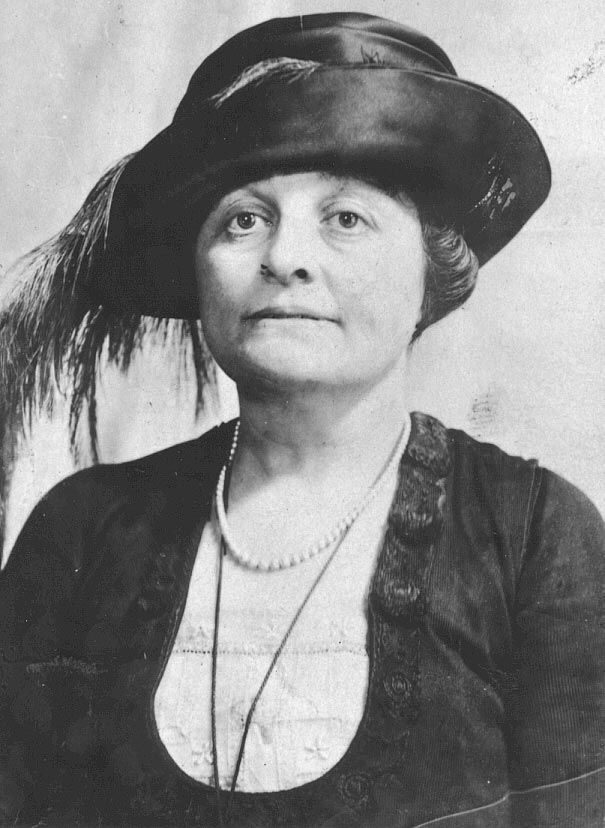

In [ ]:
from IPython.display import display, HTML
import base64

with open("Tillie.jpeg", "rb") as image_file:
    encoded = base64.b64encode(image_file.read()).decode()

html = f'''
<h3>Tillie Mandelbaum – archival photo</h3>
<p>The photo shows Tillie Mandelbaum, a Titanic passenger and wife of Emil Taussig. Archival material allows us to better understand the historical background of the people who were on board.</p>
<img src="data:image/jpeg;base64,{encoded}" width="400"/>
<p style="font-style: italic;">Tillie Taussig (née Mandelbaum) survived the disaster on lifeboat number 8 along with her daughter Ruth.</p>
'''

display(HTML(html))

## In my opinion, this is a fascinating discovery and an excellent example of how combining data analysis with classical historical research can provide deeper context and bring “dry” numbers to life.

### The recurring ticket number (110413) clearly indicates that the Taussig family traveled together - mother, father, and daughter. The consistency of surname, age, destination, and the `sibsp` / `parch` fields confirms this perfectly. The entry in parentheses (Tillie Mandelbaum) represents the woman’s full name - identified as the wife of Mr Emil Taussig, that is, Tillie née Mandelbaum. Such notation was common at the time: women were often recorded as “wife of Mr X”, with their actual given name and maiden surname provided in parentheses. Therefore, entries in parentheses refer exclusively to married women and represent their maiden names.

### A raw dataset in the form of a CSV file or DataFrame contains hidden micro-narratives that can be uncovered by linking the data with historical context.

### This is an example of how EDA (exploratory data analysis) becomes a tool for discovering facts, not just numbers. The consistency between the DataFrame data and well-documented historical facts is striking. The ticket price is nearly identical: 79.65 in the dataset versus 79.13 in historical sources. The cabin number also matches (E67). The daughter was located in the adjacent cabin (E68). The lifeboat number likewise corresponds to reality (8).

### What is both striking and tragic is that in the lifeboat column next to Mr Emil Taussig’s name, the value is `NaN`, because he remained on board and did not survive. Mrs Tillie’s account confirms the historical findings established earlier in the analysis.


---

### Examining the `cabin` column

In [ ]:
multiple_cabins = df[df['cabin'].notna() & df['cabin'].str.contains(' ')]

print("Rows with multiple cabins in one cell:")
print(multiple_cabins[['cabin']])

Wiersze z wieloma kabinami w jednej komórce:
                cabin
1             C22 C26
2             C22 C26
3             C22 C26
4             C22 C26
10            C62 C64
11            C62 C64
16            B58 B60
17            B58 B60
49        B51 B53 B55
50        B51 B53 B55
51        B51 B53 B55
54            B96 B98
55            B96 B98
56            B96 B98
57            B96 B98
97            B58 B60
111       C23 C25 C27
112       C23 C25 C27
113       C23 C25 C27
114       C23 C25 C27
115       C23 C25 C27
116       C23 C25 C27
140           D10 D12
141           D10 D12
142           B82 B84
170       B52 B54 B56
249   B57 B59 B63 B66
250   B57 B59 B63 B66
251   B57 B59 B63 B66
252   B57 B59 B63 B66
253   B57 B59 B63 B66
285           C55 C57
286           C55 C57
319           E39 E41
605             F G63
873             F G63
941             F E57
994             F E46
1024            F G73
1122            F E69
1217            F G73


### The above list of cabin numbers tells us little, so we will compare entire rows 

In [ ]:
multiple_cabins = df[df['cabin'].notna() & df['cabin'].str.contains(' ')]

print(f"Number of rows with multiple entries in the 'cabin' column: {len(multiple_cabins)}")

from IPython.display import display
display(multiple_cabins)

Liczba wierszy z wieloma wpisami w kolumnie 'cabin': 41


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
10,1.0,0.0,"Astor, Col. John Jacob",male,47.0000,1.0,0.0,PC 17757,227.5250,C62 C64,C,NaN,124.0,"New York, NY"
11,1.0,1.0,"Astor, Mrs. John Jacob (Madeleine Talmadge Force)",female,18.0000,1.0,0.0,PC 17757,227.5250,C62 C64,C,4,NaN,"New York, NY"
16,1.0,0.0,"Baxter, Mr. Quigg Edmond",male,24.0000,0.0,1.0,PC 17558,247.5208,B58 B60,C,NaN,NaN,"Montreal, PQ"
17,1.0,1.0,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",female,50.0000,0.0,1.0,PC 17558,247.5208,B58 B60,C,6,NaN,"Montreal, PQ"
49,1.0,1.0,"Cardeza, Mr. Thomas Drake Martinez",male,36.0000,0.0,1.0,PC 17755,512.3292,B51 B53 B55,C,3,NaN,"Austria-Hungary / Germantown, Philadelphia, PA"
50,1.0,1.0,"Cardeza, Mrs. James Warburton Martinez (Charlo...",female,58.0000,0.0,1.0,PC 17755,512.3292,B51 B53 B55,C,3,NaN,"Germantown, Philadelphia, PA"


### Conclusion: Relationship between surnames and multiplicity of cabin numbers

Analysis of rows where the `cabin` column contains more than one number shows a direct relationship between repeating surnames and assigned cabin numbers. For example, rows **1 to 4**, **10 and 11**, **16 and 17**, **54 to 57**, or **111 to 116**, etc. represent passengers with the same surnames assigned to identical or similar sets of cabins.

This means that **multiplicity of cabin numbers** in one cell most often indicates **people traveling together**, most likely family members or close travel companions. Such a pattern may be important in further analysis of passenger groups, their survival chances, or allocation of seats in lifeboats.


---

### Examining the `boat` column

In [85]:
multi_boat_mask = df['boat'].apply(
    lambda x: isinstance(x, str) and len([b for b in re.split(r'[,\s]+', x.strip()) if b]) > 1
)

df_multi_boat = df[multi_boat_mask]

print(df_multi_boat.to_string(index=False))

 pclass  survived                                              name    sex  age  sibsp  parch ticket    fare cabin embarked    boat  body                         home.dest
    1.0       1.0                            Daly, Mr. Peter Denis    male 51.0    0.0    0.0 113055 26.5500   E17        S     5 9   NaN                        Lima, Peru
    1.0       1.0                          Taylor, Mr. Elmer Zebley   male 48.0    1.0    0.0  19996 52.0000  C126        S     5 7   NaN         London /  East Orange, NJ
    1.0       1.0 Taylor, Mrs. Elmer Zebley (Juliet Cummins Wright) female  NaN    1.0    0.0  19996 52.0000  C126        S     5 7   NaN         London /  East Orange, NJ
    1.0       1.0                          Willard, Miss. Constance female 21.0    0.0    0.0 113795 26.5500   NaN        S    8 10   NaN                        Duluth, MN
    3.0       1.0                          Daly, Mr. Eugene Patrick   male 29.0    0.0    0.0 382651  7.7500   NaN        Q 13 15 B   NaN  C

### At this stage, we leave 10 rows with potentially distorted data without further analysis. They constitute less than 1% of the entire dataset, which qualifies them as a negligible fraction of data. They are not outliers or seriously damaged values that could significantly affect the results of predictive models or disrupt visualizations. Their analytical impact is currently considered marginal.

---

## RETURNING TO STANDARD EDA ANALYSIS !!!
## *Because I can endlessly split hairs, search, investigate...*
## *I'll soon find out who was the manufacturer and what the chair seat upholstery was made of...*

---

### Checking for suspicious values (e.g., zero or negative numbers where they should not be).

In [19]:
(df.select_dtypes(include='number') < 0).sum()

pclass      0
survived    0
age         0
sibsp       0
parch       0
fare        0
body        0
dtype: int64

### Checking for possible duplicates

In [18]:
df.duplicated().sum()

0

### Checking data types

In [22]:
df.dtypes

pclass       float64
survived     float64
name          object
sex           object
age          float64
sibsp        float64
parch        float64
ticket        object
fare         float64
cabin         object
embarked      object
boat          object
body         float64
home.dest     object
dtype: object

### Checking unique values

In [9]:
df.nunique()

pclass          3
survived        2
name         1307
sex             2
age            98
sibsp           7
parch           8
ticket        929
fare          281
cabin         186
embarked        3
boat           27
body          121
home.dest     369
dtype: int64

### Checking the number of complete rows / we already know it should be 0, each row contains at least one missing value, but let's check if it's confirmed

In [11]:
df.dropna().shape[0] 

0

### Decision to remove the body column
The body column has been excluded from analysis; it contains extremely many missing values (over 90%) and does not directly contribute useful analytical information.

In [18]:
df = df.drop(columns='body')

df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,home.dest
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,2,"St Louis, MO"
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,11,"Montreal, PQ / Chesterville, ON"
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,"Montreal, PQ / Chesterville, ON"
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,"Montreal, PQ / Chesterville, ON"
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,"Montreal, PQ / Chesterville, ON"


### Checking how many men and women there were

In [19]:
gender_counts = df['sex'].value_counts()
gender_counts

male      843
female    466
Name: sex, dtype: int64

### Checking how ticket prices are distributed

In [53]:
df_valid_fare = df[df['fare'] > 0]

min_fare = df_valid_fare['fare'].min()
max_fare = df_valid_fare['fare'].max()

custom_bins = np.linspace(min_fare, max_fare, num=11)

fare_bins = pd.cut(df_valid_fare['fare'], bins=custom_bins).value_counts().sort_index()

fare_description = df_valid_fare['fare'].describe().round(2)

fare_description, fare_bins

(count    1291.00
 mean       33.73
 std        51.96
 min         3.17
 25%         7.92
 50%        14.50
 75%        31.33
 max       512.33
 Name: fare, dtype: float64,
 (3.171, 54.087]       1076
 (54.087, 105.002]      130
 (105.002, 155.918]      42
 (155.918, 206.834]       4
 (206.834, 257.75]       21
 (257.75, 308.666]       13
 (308.666, 359.582]       0
 (359.582, 410.498]       0
 (410.498, 461.413]       0
 (461.413, 512.329]       4
 Name: fare, dtype: int64)

### More visually

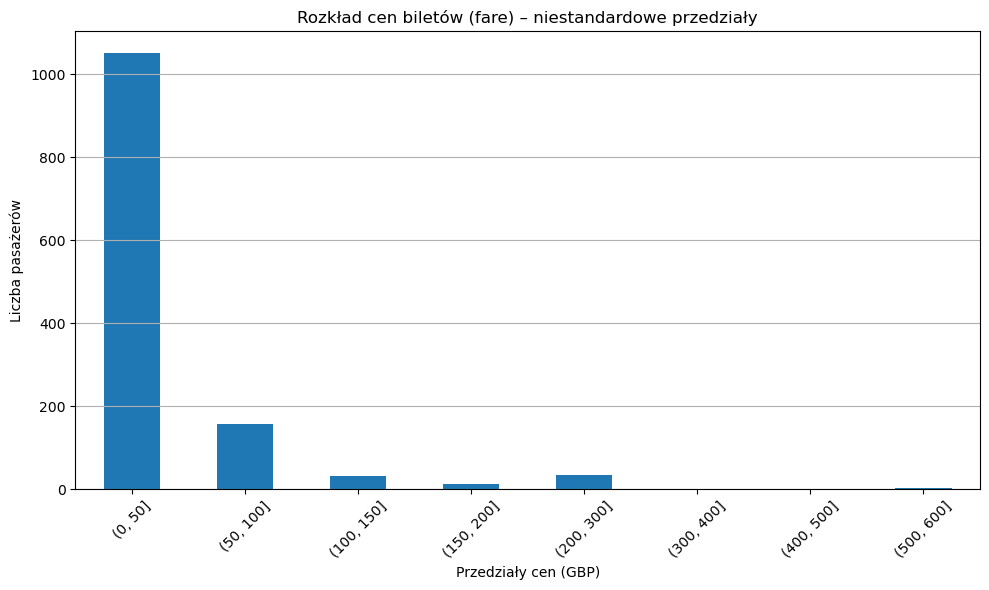

In [ ]:
import matplotlib.pyplot as plt

custom_bins = [0, 50, 100, 150, 200, 300, 400, 500, 600]
fare_bin_labels = pd.cut(df['fare'], bins=custom_bins)
fare_bin_counts = fare_bin_labels.value_counts().sort_index()

plt.figure(figsize=(10, 6))
fare_bin_counts.plot(kind='bar')
plt.title('Distribution of ticket prices (fare) – custom intervals')
plt.xlabel('Price intervals (GBP)')
plt.ylabel('Number of passengers')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### Checking what percentage of people traveled alone and what percentage in groups

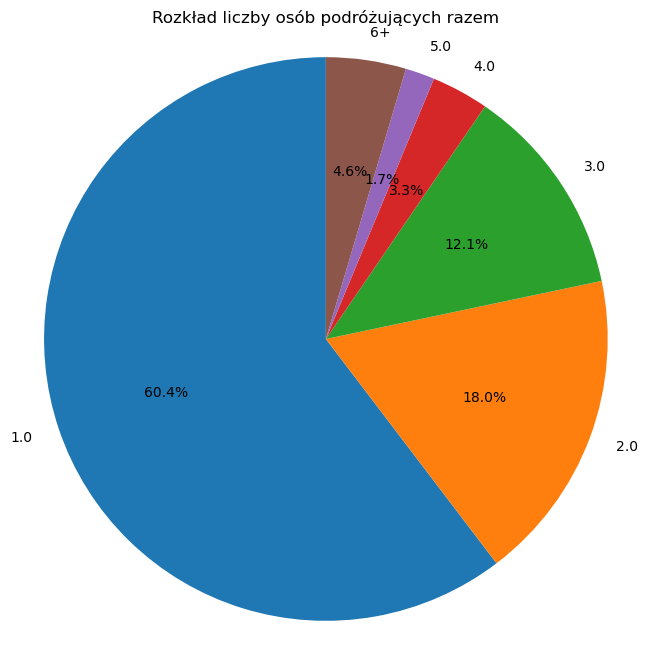

In [ ]:
df['travel_group_size'] = df['sibsp'] + df['parch'] + 1

group_counts = df['travel_group_size'].value_counts().sort_index()

group_counts_reduced = group_counts.copy()
group_counts_reduced.index = group_counts_reduced.index.map(lambda x: str(x) if x < 6 else '6+')
group_counts_reduced = group_counts_reduced.groupby(group_counts_reduced.index).sum()

plt.figure(figsize=(8, 8))
plt.pie(group_counts_reduced, labels=group_counts_reduced.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of number of people traveling together')
plt.axis('equal')
plt.show()

## Despite the boat column being empty in over 60%, we will allow ourselves a few charts

### Checking lifeboat assignment by gender

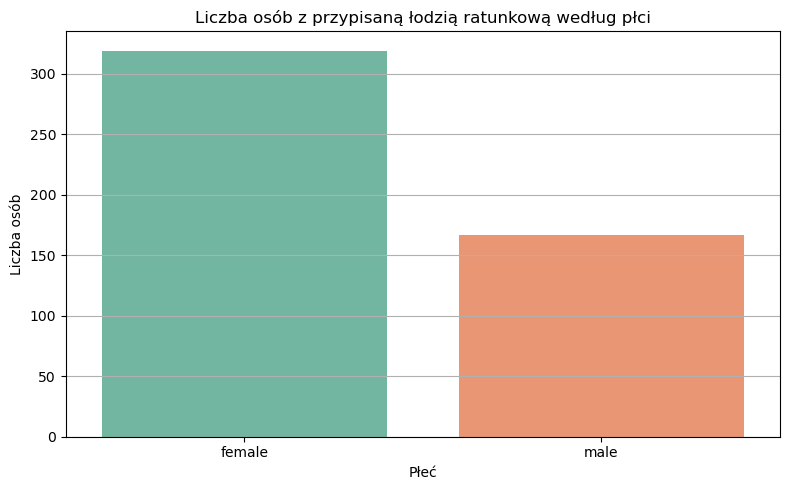

,Płeć,Liczba osób z przypisaną łodzią
0,female,319
1,male,167


In [ ]:
df_lodka = df[df['boat'].notna()]

liczba_osob_z_lodzia = df_lodka['sex'].value_counts()

tabela_lodz = liczba_osob_z_lodzia.reset_index()
tabela_lodz.columns = ['Gender', 'Number of people with assigned lifeboat']

plt.figure(figsize=(8, 5))
sns.barplot(data=tabela_lodz, x='Gender', y='Number of people with assigned lifeboat', palette='Set2')
plt.title('Number of people with assigned lifeboat by gender')
plt.ylabel('Number of people')
plt.xlabel('Gender')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

tabela_lodz

### Checking survival by gender for people with assigned lifeboat

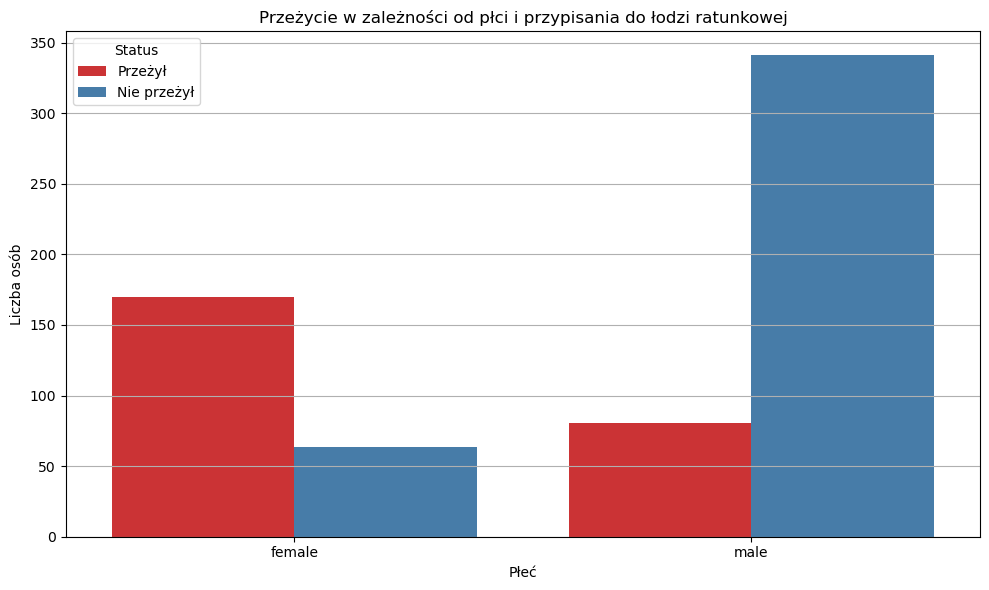

In [ ]:
df_plot = df.copy()
df_plot['boat_assigned'] = df_plot['boat'].notna()
df_plot['status'] = df_plot['survived'].map({0: 'Did not survive', 1: 'Survived'})

grupowanie = df_plot.groupby(['sex', 'boat_assigned', 'status']).size().reset_index(name='Number of people')

plt.figure(figsize=(10, 6))
sns.barplot(
    data=grupowanie,
    x='sex',
    y='Number of people',
    hue='status',
    palette='Set1',
    errorbar=None,
    dodge=True,
    hue_order=['Survived', 'Did not survive']
)

plt.title('Survival by gender and lifeboat assignment')
plt.xlabel('Gender')
plt.ylabel('Number of people')
plt.grid(axis='y')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

### Checking how many people survived and how many died

In [ ]:
survival_counts = df['survived'].value_counts()
survival_percent = df['survived'].value_counts(normalize=True) * 100
summary = pd.DataFrame({
    'Number of people': survival_counts,
    'Percentage': survival_percent.round(2)
})
summary.index = ['Did not survive', 'Survived']
summary

,Liczba osób,Procent
Nie przeżył,809,61.8
Przeżył,500,38.2


### Bardziej obrazowo

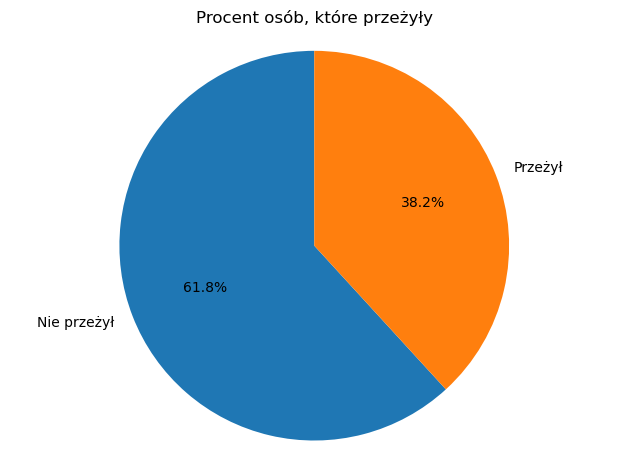

In [ ]:
df['survived'].map({0: 'Did not survive', 1: 'Survived'}).value_counts().plot(
    kind='pie', autopct='%1.1f%%', startangle=90
)
plt.title('Percentage of people who survived')
plt.ylabel('')
plt.axis('equal')
plt.tight_layout()
plt.show()

### Checking survival relationship: women - men

        Liczba osób  Liczba ocalałych  survival_rate (%)
sex                                                     
female          466             339.0              72.75
male            843             161.0              19.10


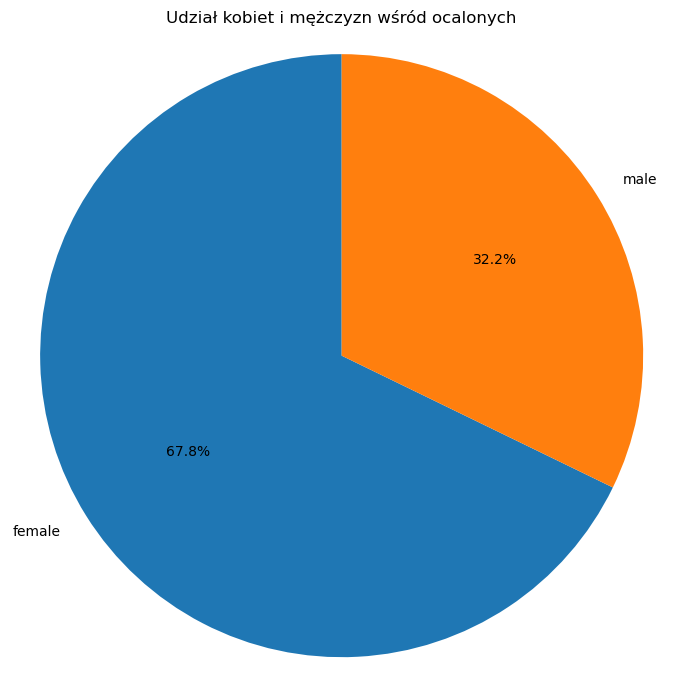

In [ ]:
survival_by_sex = df.groupby('sex')['survived'].agg(['count', 'sum'])
survival_by_sex['survival_rate (%)'] = (survival_by_sex['sum'] / survival_by_sex['count'] * 100).round(2)
survival_by_sex = survival_by_sex.rename(columns={'count': 'Number of people', 'sum': 'Number of survivors'})

print(survival_by_sex)

survived_by_sex = df[df['survived'] == 1]['sex'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(survived_by_sex, labels=survived_by_sex.index, autopct='%1.1f%%', startangle=90)
plt.title('Share of women and men among survivors')
plt.axis('equal')
plt.tight_layout()
plt.show()

### Checking survival for classes 1, 2, and 3

Tabela przeżywalności względem klasy:

        Liczba osób  Liczba ocalałych  survival_rate (%)
pclass                                                  
1.0             323             200.0              61.92
2.0             277             119.0              42.96
3.0             709             181.0              25.53


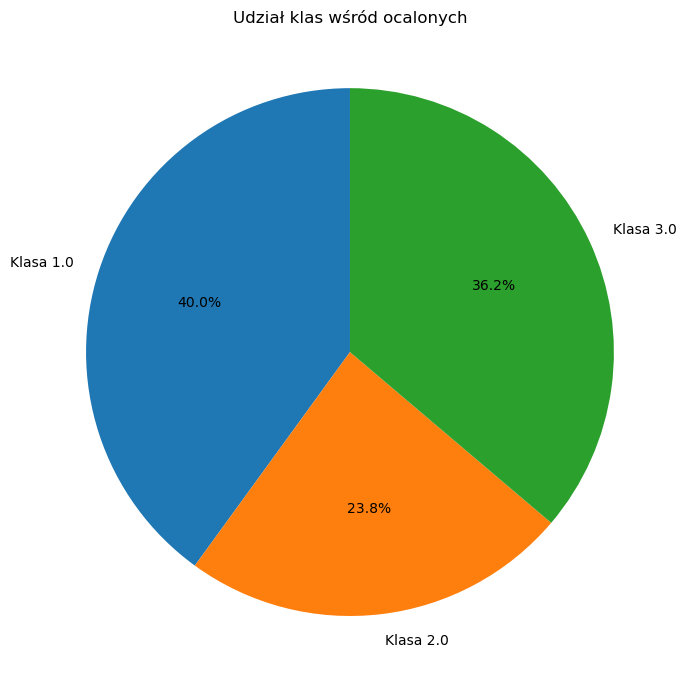

In [ ]:
survival_by_class = df.groupby('pclass')['survived'].agg(['count', 'sum'])
survival_by_class['survival_rate (%)'] = (survival_by_class['sum'] / survival_by_class['count'] * 100).round(2)
survival_by_class = survival_by_class.rename(columns={'count': 'Number of people', 'sum': 'Number of survivors'})

print("Survival table by class:\n")
print(survival_by_class)

survived_by_class = df[df['survived'] == 1]['pclass'].value_counts().sort_index()

plt.figure(figsize=(7, 7))
plt.pie(survived_by_class, labels=[f'Class {i}' for i in survived_by_class.index],
        autopct='%1.1f%%', startangle=90)
plt.title('Share of classes among survivors')
plt.axis('equal')
plt.tight_layout()
plt.show()

### Let's look at the `fare` column, it seems to be one of the simplest to fix

In [ ]:
fare_zero = df[df['fare'] == 0].groupby('pclass').size().rename('Number of fare = 0')

fare_nan = df[df['fare'].isna()].groupby('pclass').size().rename('Number of fare = NaN')

fare_issues_split = pd.concat([fare_zero, fare_nan], axis=1).fillna(0).astype(int)
fare_issues_split

,Liczba fare = 0,Liczba fare = NaN
pclass,,
1.0,7,0
2.0,6,0
3.0,4,1


### Let's examine how ticket prices looked by class

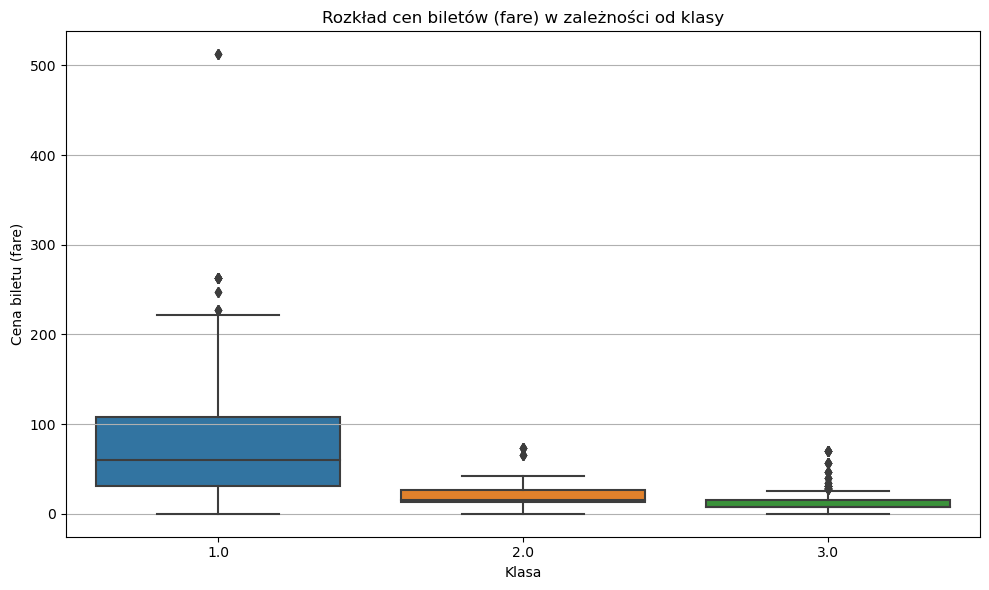

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='pclass', y='fare')
plt.title('Distribution of ticket prices (fare) by class')
plt.xlabel('Class')
plt.ylabel('Ticket price (fare)')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

### Conclusion: many people shared one ticket (e.g., family), the entire group had the same ticket price assigned, so this price appears multiple times, artificially increasing the impact of one value on the distribution.

### To minimize distortion, we will calculate the average price per person for each ticket

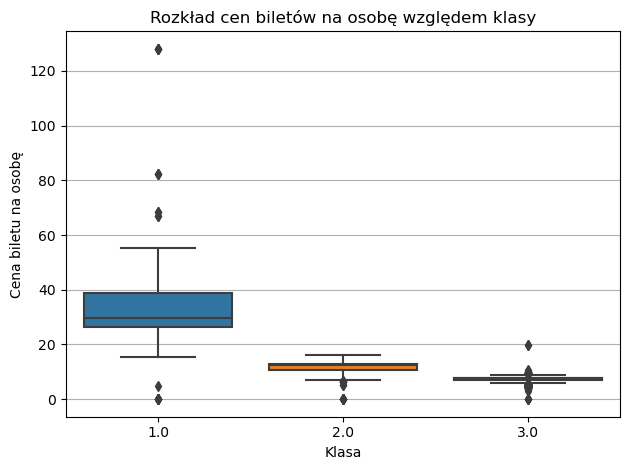

In [ ]:
ticket_group_sizes = df['ticket'].value_counts()

df['passengers_per_ticket'] = df['ticket'].map(ticket_group_sizes)

df['fare_per_person'] = df['fare'] / df['passengers_per_ticket']

sns.boxplot(data=df, x='pclass', y='fare_per_person')
plt.title('Distribution of ticket prices per person by class')
plt.xlabel('Class')
plt.ylabel('Ticket price per person')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

### The distribution looks almost identical, but the price values have dropped significantly

### Before we calculate the average ticket price for each class and fill in values 0 and NaN (of course on a copy), we will check if we have NaN in the pclass column

In [46]:
missing_pclass_count = df['pclass'].isna().sum()
missing_pclass_count

1

### We'll have to live with that 1 somehow 

In [45]:
df_filled = df.copy()

mean_fare_by_class = df_filled[df_filled['fare'] > 0].groupby('pclass')['fare'].mean()

def fill_fare(row):
    if pd.isna(row['fare']) or row['fare'] == 0:
        if pd.notna(row['pclass']) and row['pclass'] in mean_fare_by_class:
            return mean_fare_by_class[row['pclass']]
        else:
            return row['fare']  
    else:
        return row['fare']

df_filled['fare'] = df_filled.apply(fill_fare, axis=1)

df_filled[df['fare'] != df_filled['fare']][['pclass', 'fare']]

,pclass,fare
7,1.0,89.447482
70,1.0,89.447482
125,1.0,89.447482
150,1.0,89.447482
170,1.0,89.447482
223,1.0,89.447482
234,1.0,89.447482
363,2.0,21.648108
384,2.0,21.648108
410,2.0,21.648108


### The NaN value at the bottom prevents filling in the ticket price `fare` for this row, because it is not known which class to assign the mean to.  

### Checking min, mean, and max price after filling in missing data 

Statystyki cen biletów po uzupełnieniu braków (df_filled):

        Minimalna cena  Średnia cena  Maksymalna cena
pclass                                               
1.0               5.00         89.45           512.33
2.0               9.69         21.65            73.50
3.0               3.17         13.38            69.55


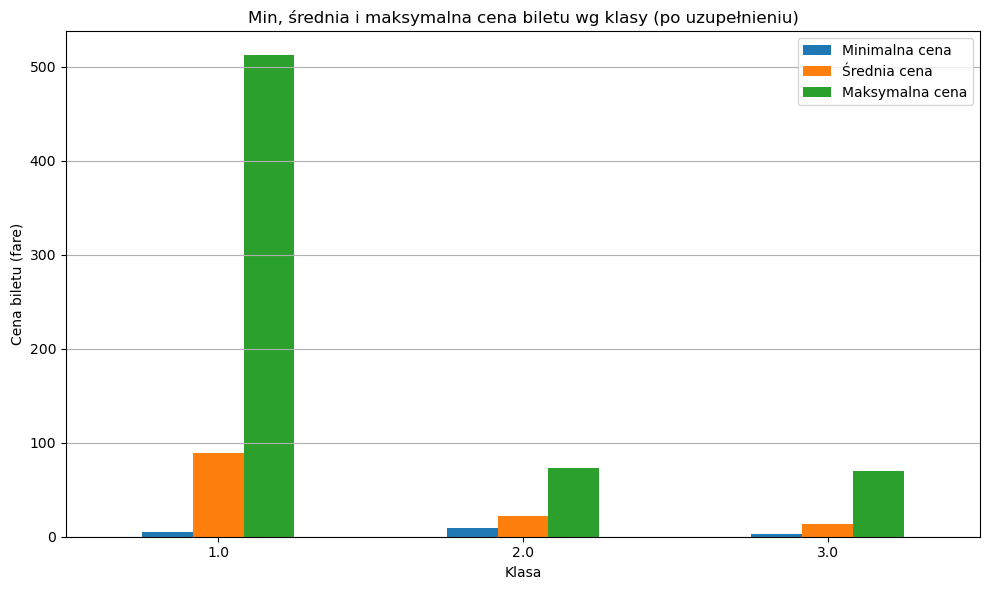

In [ ]:
grupy_klas = df_filled.groupby('pclass')

statystyki_fare = grupy_klas['fare'].agg(['min', 'mean', 'max']).round(2)

statystyki_fare = statystyki_fare.rename(columns={
    'min': 'Minimum price',
    'mean': 'Mean price',
    'max': 'Maximum price'
})

print("Ticket price statistics after filling missing values (df_filled):\n")
print(statystyki_fare)

statystyki_fare.plot(kind='bar', figsize=(10, 6))
plt.title('Min, mean, and max ticket price by class (after filling)')
plt.xlabel('Class')
plt.ylabel('Ticket price (fare)')
plt.grid(axis='y')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

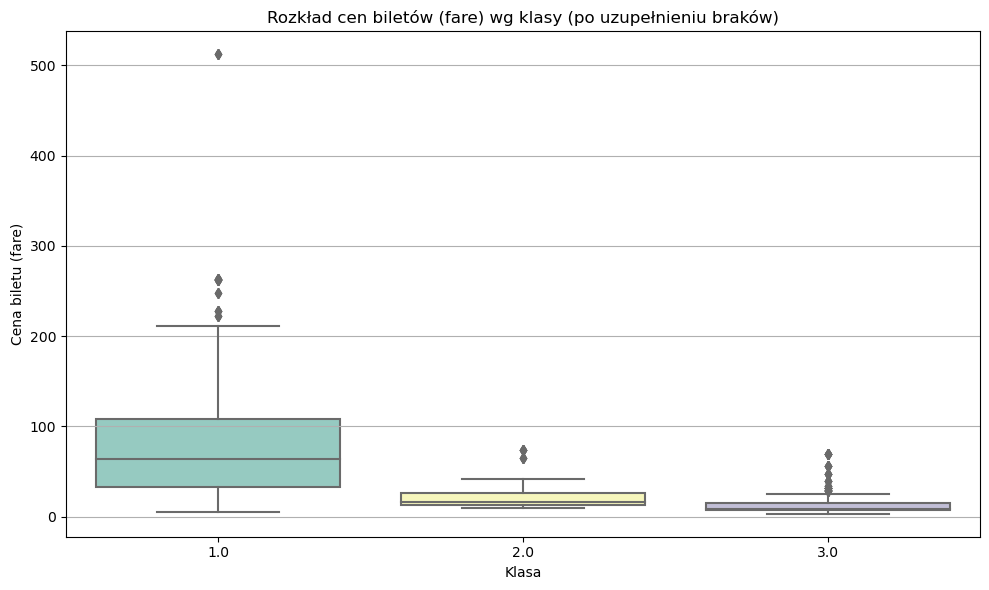

In [ ]:
df_filled = df.copy()
for cls in df_filled['pclass'].unique():
    mean_fare = df_filled.loc[(df_filled['pclass'] == cls) & (df_filled['fare'] > 0), 'fare'].mean()
    df_filled.loc[(df_filled['pclass'] == cls) & ((df_filled['fare'] == 0) | (df_filled['fare'].isna())), 'fare'] = mean_fare

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_filled, x='pclass', y='fare', palette='Set3')
plt.title('Distribution of ticket prices (fare) by class (after filling missing values)')
plt.xlabel('Class')
plt.ylabel('Ticket price (fare)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### Checking approximate White Star Line revenue from tickets

In [ ]:
suma_biletow = df_filled['fare'].sum().round(2)

print(f"Sum of all ticket prices in df_filled: {suma_biletow} currency units")

Suma wszystkich cen biletów w df_filled: 44373.4 jednostek waluty


### Surprisingly little, but we need to add revenue from mail and cargo transport, maybe advertising and prestige

### Checking the relationship between all passengers in a given class and survivors

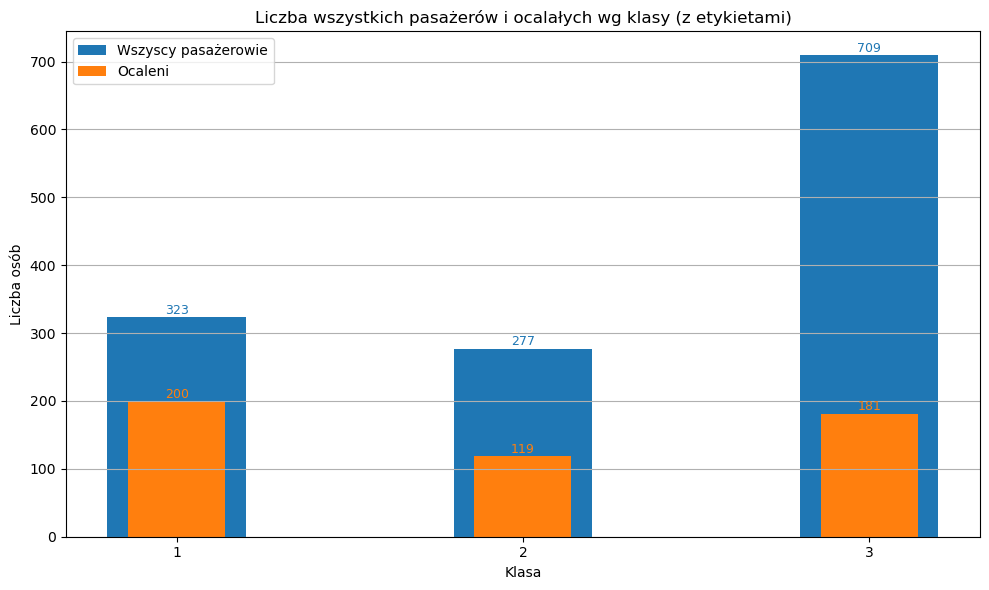

In [ ]:
wszyscy = df['pclass'].value_counts().sort_index()
przezyli = df[df['survived'] == 1]['pclass'].value_counts().sort_index()

dane = pd.DataFrame({
    'All passengers': wszyscy,
    'Survivors': przezyli
}).fillna(0).astype(int)

index = dane.index
bar_width = 0.4

plt.figure(figsize=(10, 6))

bars_all = plt.bar(index, dane['All passengers'], width=bar_width, label='All passengers', color='#1f77b4')
bars_surv = plt.bar(index, dane['Survivors'], width=bar_width * 0.7, label='Survivors', color='#ff7f0e')

for bar in bars_all:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5, str(height), ha='center', fontsize=9, color='#1f77b4')

for bar in bars_surv:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5, str(height), ha='center', fontsize=9, color='#ff7f0e')

plt.title('Number of all passengers and survivors by class (with labels)')
plt.xlabel('Class')
plt.ylabel('Number of people')
plt.xticks(index)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### Bubble charts: class vs. ticket price and deck vs. ticket price 

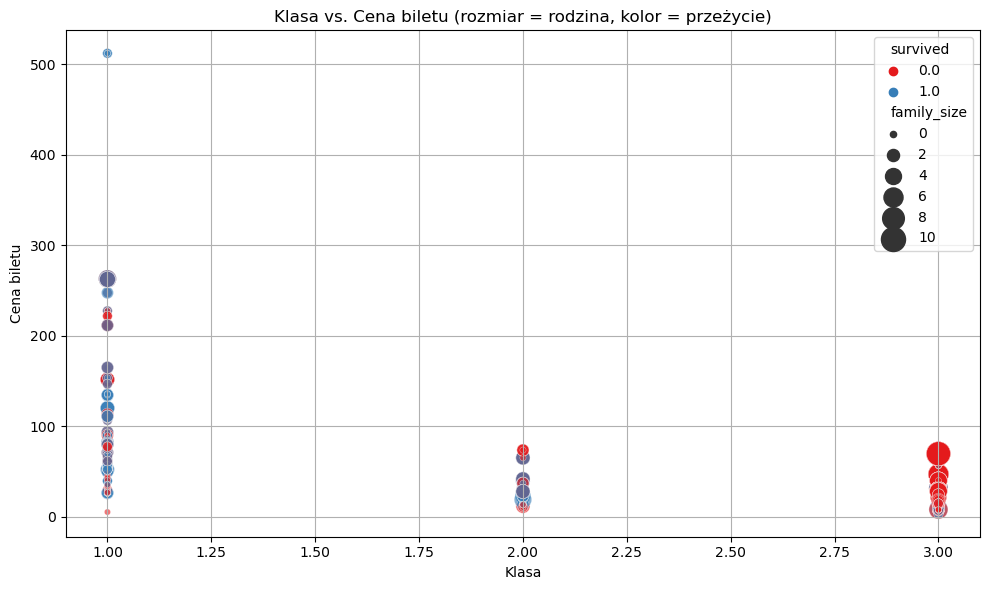

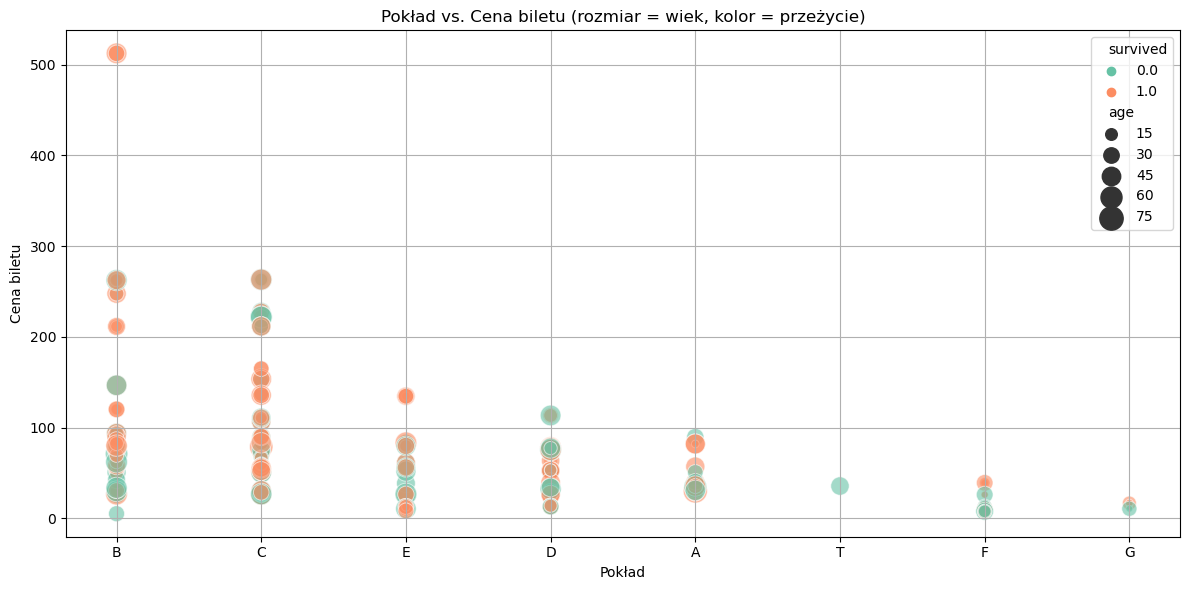

In [ ]:
df_filled['family_size'] = df_filled['sibsp'] + df_filled['parch']
df_bubble_2 = df_filled[df_filled['fare'] > 0]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_bubble_2,
    x='pclass',
    y='fare',
    size='family_size',
    hue='survived',
    sizes=(20, 300),
    alpha=0.6,
    palette='Set1',
    marker='o'
)
plt.title('Class vs. Ticket price (size = family, color = survival)')
plt.xlabel('Class')
plt.ylabel('Ticket price')
plt.grid(True)
plt.tight_layout()
plt.show()

df_filled['deck'] = df_filled['cabin'].str[0]
df_bubble_3 = df_filled[(df_filled['fare'] > 0) & (df_filled['age'].notna()) & (df_filled['deck'].notna())]

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df_bubble_3,
    x='deck',
    y='fare',
    size='age',
    hue='survived',
    sizes=(20, 300),
    alpha=0.6,
    palette='Set2',
    marker='o'
)
plt.title('Deck vs. Ticket price (size = age, color = survival)')
plt.xlabel('Deck')
plt.ylabel('Ticket price')
plt.grid(True)
plt.tight_layout()
plt.show()

### Ticket price vs. age

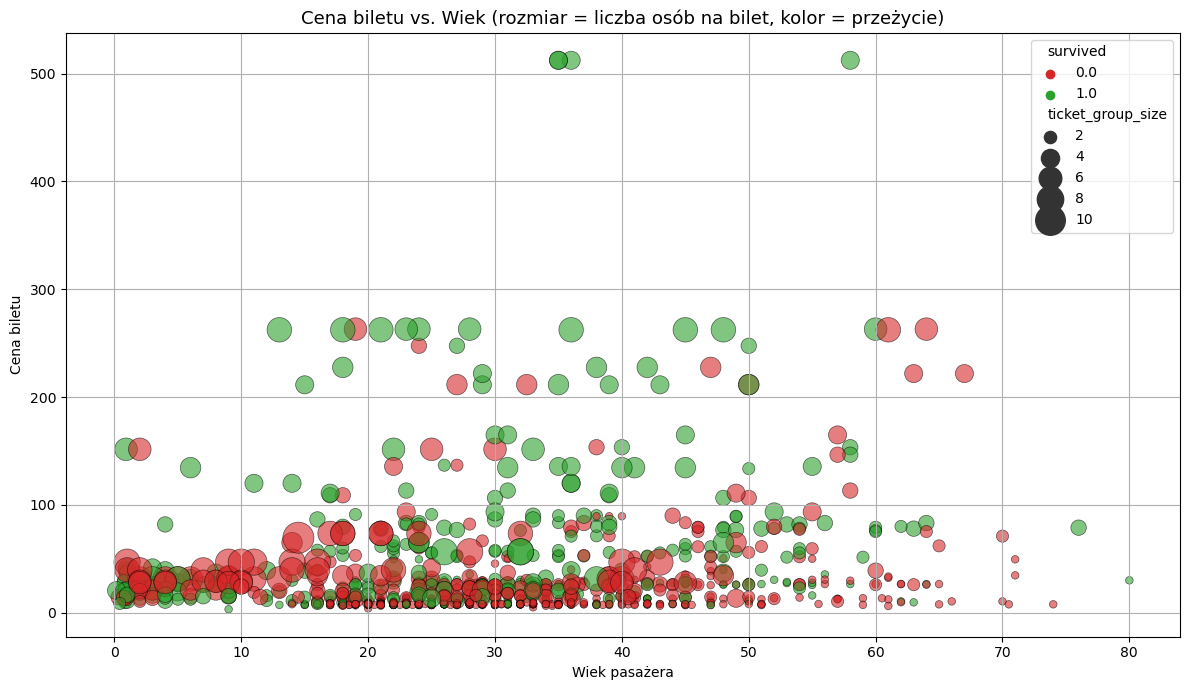

In [ ]:
df_filled['ticket_group_size'] = df_filled['ticket'].map(df_filled['ticket'].value_counts())

df_bubble_free = df_filled[(df_filled['fare'] > 0) & (df_filled['age'].notna())]

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df_bubble_free,
    x='age',
    y='fare',
    size='ticket_group_size',
    hue='survived',
    sizes=(30, 500),
    alpha=0.6,
    palette={0: '#d62728', 1: '#2ca02c'},  
    marker='o',
    edgecolor='black',
    linewidth=0.5
)

plt.title('Ticket price vs. Age (size = number of people per ticket, color = survival)', fontsize=13)
plt.xlabel('Passenger age')
plt.ylabel('Ticket price')
plt.grid(True)
plt.tight_layout()
plt.show()

### Checking passenger age by class

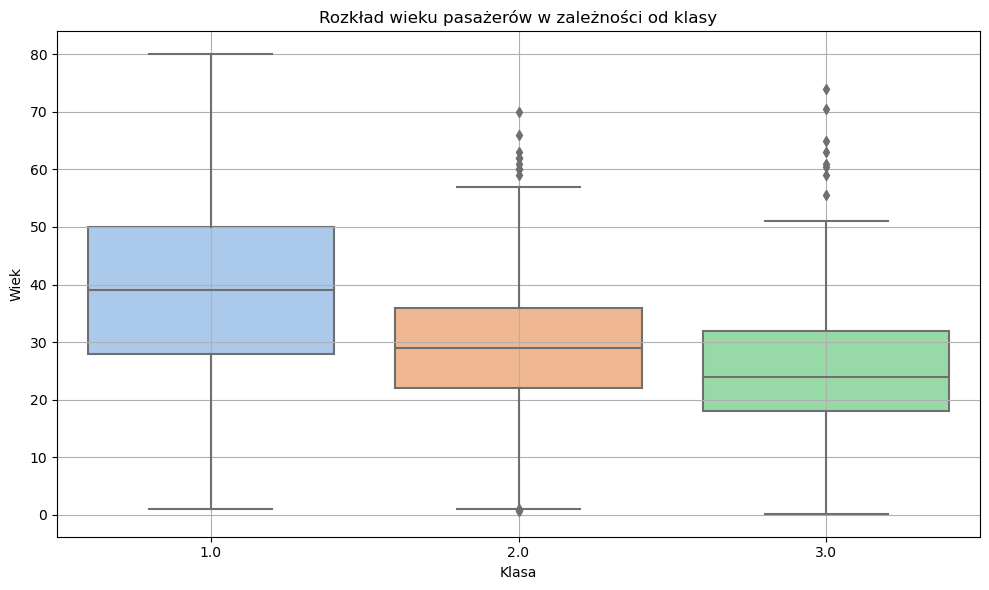

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='pclass',
    y='age',
    palette='pastel'
)

plt.title('Distribution of passenger age by class')
plt.xlabel('Class')
plt.ylabel('Age')
plt.grid(True)
plt.tight_layout()
plt.show()

### Correlation matrix of numeric variables for classes 1, 2, and 3

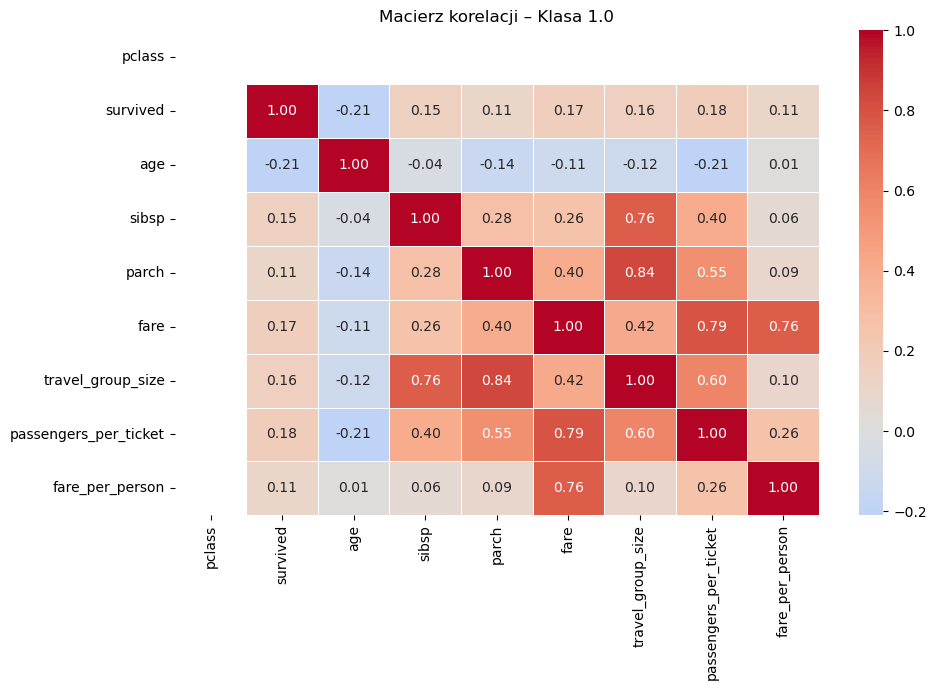

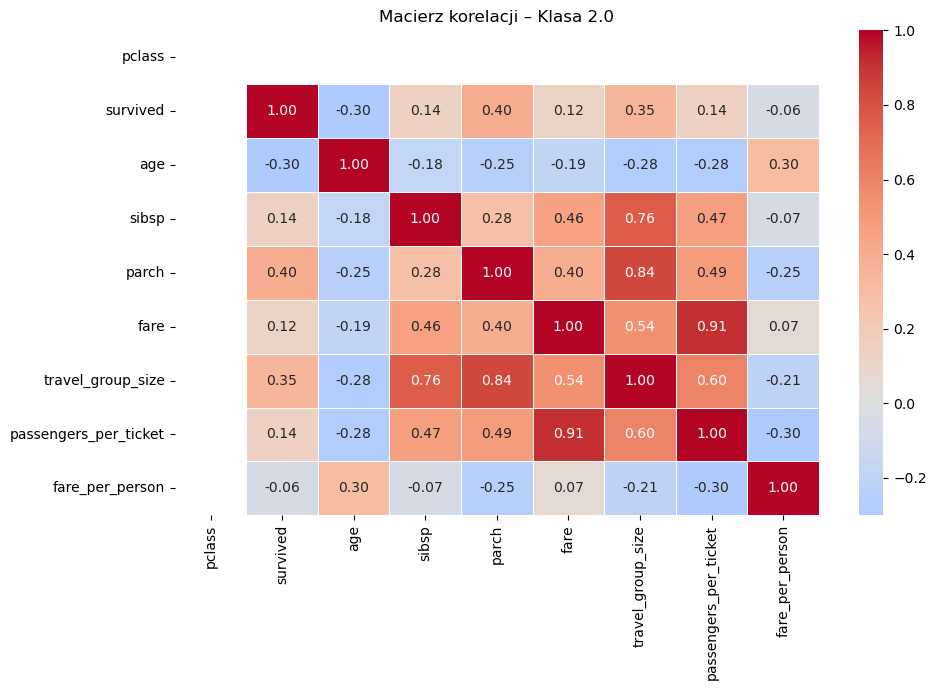

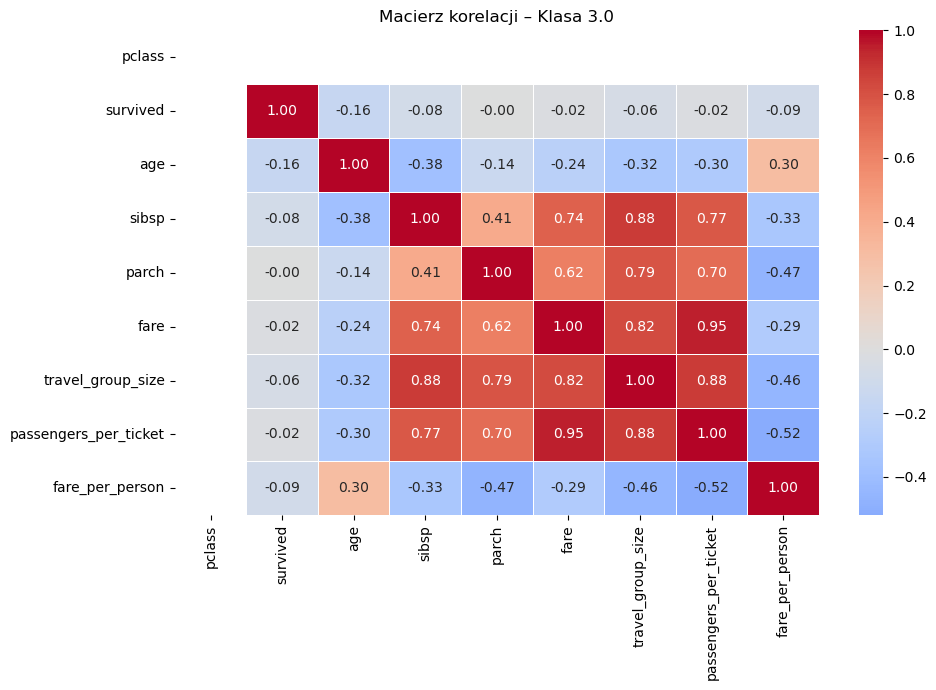

In [ ]:
korelacje_klas = {}

for klasa in sorted(df['pclass'].unique()):
    dane_klasy = df[df['pclass'] == klasa].select_dtypes(include='number')
    korelacja = dane_klasy.corr().round(2)
    korelacje_klas[f'Class {klasa}'] = korelacja

for klasa, corr_matrix in korelacje_klas.items():
    if corr_matrix.isnull().all().all():
        continue

    plt.figure(figsize=(10, 7))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.5, fmt=".2f")
    plt.title(f'Correlation matrix – {klasa}')
    plt.tight_layout()
    plt.show()


## Finally, a small challenge: the `age` column and an attempt to fill it

### Assumption 1 - if several people have the same surname, they are probably a family. If among them only one person is missing age, and the rest are adults, we can assume it is, for example, a child. We assume 10 years as the mean value

In [83]:
df_rodzina = df.copy()

df_rodzina['nazwisko'] = df_rodzina['name'].str.extract(r'^([^,]+)', expand=False)

grupy_nazwisk = df_rodzina.groupby('nazwisko')

do_uzupelnienia = []

for nazwisko, grupa in grupy_nazwisk:
    if len(grupa) >= 3 and grupa['age'].isna().sum() == 1:
        znane_wieki = grupa['age'].dropna()
        if all(znane_wieki > 18): 
            idx_nan = grupa[grupa['age'].isna()].index[0]
            do_uzupelnienia.append(idx_nan)

df_rodzina.loc[do_uzupelnienia, 'age'] = 10

df_rodzina.loc[do_uzupelnienia, ['name', 'age', 'nazwisko']]

,name,age,nazwisko
682,"Bourke, Miss. Mary",10.0,Bourke
121,"Frauenthal, Mrs. Henry William (Clara Heinshei...",10.0,Frauenthal
872,"Howard, Miss. May Elizabeth",10.0,Howard
166,"Hoyt, Mr. William Fisher",10.0,Hoyt
204,"Meyer, Mrs. Edgar Joseph (Leila Saks)",10.0,Meyer
1282,"Ware, Mr. Frederick",10.0,Ware
1283,"Warren, Mr. Charles William",10.0,Warren


### Checking what remains

In [85]:
df_rodzina['age'].isna().sum()

257

### Assumption 2 - people with the same surname with one NaN are probably spouses, if age is missing for a man, we add 5 years to the partner, if age is missing for a woman, we subtract 5 years from the partner

In [86]:
df_malzenstwo = df.copy()
df_malzenstwo['nazwisko'] = df_malzenstwo['name'].str.extract(r'^([^,]+)', expand=False)

uzupelnienia_maz_zona = []

for nazwisko, grupa in df_malzenstwo.groupby('nazwisko'):
    if len(grupa) == 2 and grupa['age'].isna().sum() == 1:
        idx_nan = grupa[grupa['age'].isna()].index[0]
        idx_known = grupa[grupa['age'].notna()].index[0]
        wiek_znany = grupa.loc[idx_known, 'age']
        plec_brakujaca = grupa.loc[idx_nan, 'sex']

        if plec_brakujaca == 'male':
            wiek_szacowany = wiek_znany + 5
        else:
            wiek_szacowany = max(wiek_znany - 5, 15)

        df_malzenstwo.loc[idx_nan, 'age'] = round(wiek_szacowany)
        uzupelnienia_maz_zona.append(idx_nan)

df_malzenstwo.loc[uzupelnienia_maz_zona, ['name', 'sex', 'age', 'nazwisko']]

,name,sex,age,nazwisko
672,"Betros, Master. Seman",male,25.0,Betros
37,"Bradley, Mr. George (""George Arthur Brayton"")",male,27.0,Bradley
804,"Foley, Mr. William",male,31.0,Foley
812,"Fox, Mr. Patrick",male,41.0,Fox
134,"Goldenberg, Mrs. Samuel L (Edwiga Grabowska)",female,44.0,Goldenberg
176,"Kenyon, Mrs. Frederick R (Marion)",female,36.0,Kenyon
999,"McCarthy, Miss. Catherine ""Katie""",female,49.0,McCarthy
1027,"Moore, Mr. Leonard Charles",male,52.0,Moore
1128,"Petroff, Mr. Pastcho (""Pentcho"")",male,24.0,Petroff
1154,"Rogers, Mr. William John",male,24.0,Rogers


### Checking 

In [89]:
df_age_filled = df.copy()

df_age_filled['nazwisko'] = df_age_filled['name'].str.extract(r'^([^,]+)', expand=False)

grupy_rodzinne = df_age_filled.groupby('nazwisko')
uzup_dzieci = []

for nazwisko, grupa in grupy_rodzinne:
    if len(grupa) >= 3 and grupa['age'].isna().sum() == 1:
        if all(grupa['age'].dropna() > 18):
            idx_nan = grupa[grupa['age'].isna()].index[0]
            df_age_filled.loc[idx_nan, 'age'] = 10
            uzup_dzieci.append(idx_nan)

uzup_malzenstwa = []

for nazwisko, grupa in grupy_rodzinne:
    if len(grupa) == 2 and grupa['age'].isna().sum() == 1:
        idx_nan = grupa[grupa['age'].isna()].index[0]
        idx_known = grupa[grupa['age'].notna()].index[0]
        wiek_znany = grupa.loc[idx_known, 'age']
        plec_brakujaca = grupa.loc[idx_nan, 'sex']

        if plec_brakujaca == 'male':
            wiek_szacowany = wiek_znany + 5
        else:
            wiek_szacowany = max(wiek_znany - 5, 15)

        df_age_filled.loc[idx_nan, 'age'] = round(wiek_szacowany)
        uzup_malzenstwa.append(idx_nan)

pozostale_nan = df_age_filled['age'].isna().sum()
suma_uzup = len(uzup_dzieci) + len(uzup_malzenstwa)

pozostale_nan, suma_uzup

(242, 22)

### Assumption 3 - (final) we fill the remaining `age` based on `sex` + `pclass`. 
### pclass
- class 1 - more often adults, older people, traveling comfortably,
- class 3 - more families, children, passengers from lower social classes.
### sex
- women - greater age spread (from children to older mothers),
- men - more concentrated around adult age (20–40 years).

In [94]:
df_age_final = df_age_filled.copy()

df_age_final['age'] = df_age_final.groupby(['sex', 'pclass'])['age'].transform(
    lambda x: x.fillna(x.median())
)

pozostale_nan_koniec = df_age_final['age'].isna().sum()
pozostale_nan_koniec

1

### The cherry on top

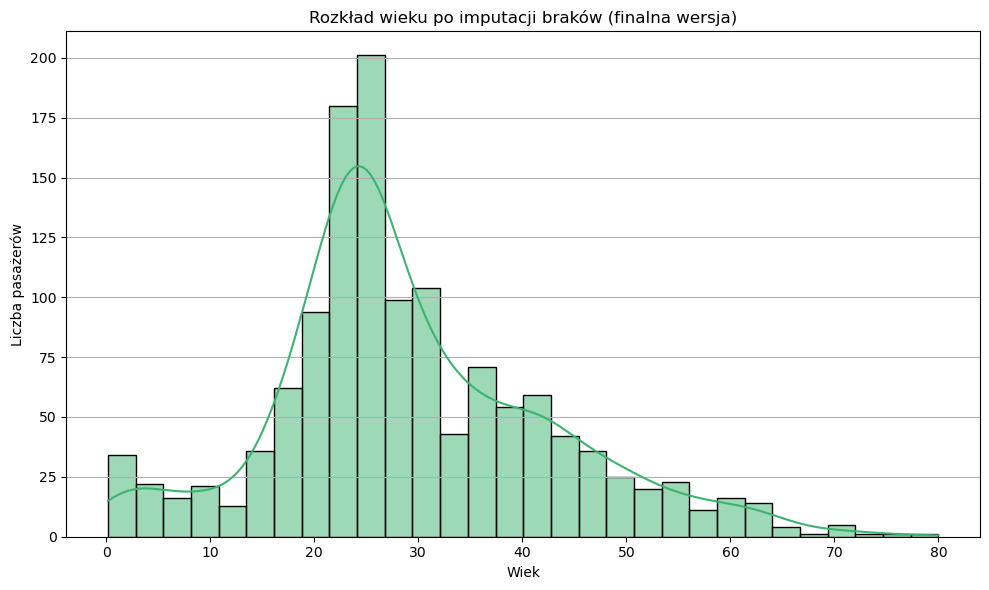

In [ ]:
df_age_final = df_age_final.drop(index=1309, errors='ignore')

plt.figure(figsize=(10, 6))
sns.histplot(df_age_final['age'], bins=30, kde=True, color='mediumseagreen')
plt.title('Age distribution after missing value imputation (final version)')
plt.xlabel('Age')
plt.ylabel('Number of passengers')
plt.grid(axis='y')
plt.tight_layout()

# Summary of Titanic Passenger Data Analysis

## Analysis Objective

The goal of the project was to understand the relationships between demographic and social characteristics of Titanic passengers and their survival. The analysis was based on tabular data, without information about rescue logistics, crew decisions, or evacuation order.

## Analysis Scope

* Examination of the impact of gender, age, travel class, and family presence on survival rate.
* Verification of historical hypotheses (e.g., "women and children first").
* Filling missing values in data while maintaining reliability.

## Data Imputation Methods

* Zero values and NaN in the `fare` column were filled with the mean ticket price for the given class.
* `age`:

  * children from family groups (>=3 people) received age 10 years,
  * marriages were filled with partner age ±5 years,
  * remaining missing values were filled with median by gender and class.
* Removed record with 14 missing values (row 1309), and the `body` column

## Key Conclusions

* **Gender**: Women had a significantly higher chance of survival than men.
* **Class**: 1st class had the highest survival rate.
* **Age**: Children survived more often, especially girls.
* **Family**: Presence of family members was often associated with higher survival.
* **Lifeboat**: Assignment to a lifeboat almost guaranteed survival.

## Missing Values and Data Structure

* Missing values present in every row and column.
* `body`, `cabin`, `boat` contained over 60% missing values.
* Columns with very large number of missing values (e.g., `body`) were deemed useless in predictive analysis.

## Example Discovery: Taussig Family

* Data matched historical information.
* Shared ticket number, cabin, price, family relationships confirmed.
* Confirmation that statistical data can reflect real human stories.

## Correlations and Visualizations

* Many charts confirmed relationships: including scatter plots, boxplots, bar and pie charts.
* Boxplots for `fare` and `age` show large spread and presence of outliers.
* Charts showing survival by class, gender, and lifeboat assignment facilitated interpretation of results.

## Limitations

* Data does not contain information about crew decisions, evacuation order, chaos on deck.
* `boat` may be an effect, not a cause of survival.

## Final Conclusions

* Titanic data allows for solid correlational analysis.
* Well-prepared dataset (e.g., through imputation) enables creation of predictive models.
* Combined with historical context, data gains depth and reveals human stories hidden behind statistics.

Titanic data analysis is a combination of data science, history, and empathy. It shows not only who survived, but how important social structure and context are in interpreting data.
